In [2]:
# ============================================================
# 1. Minimal setup for whole-brain follow-up analysis
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

from IPython.display import display

from nilearn.plotting import plot_stat_map, view_img
from nilearn.reporting import get_clusters_table
from nilearn.image import threshold_img, math_img

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
DATA_DIR = PROJECT_ROOT / "data"
BIDS_DIR = DATA_DIR / "bids_ackbar"

ANALYSIS_NAME = "memory_quality_post_viewing_parametric"

OUT_DIR = DATA_DIR / "processed" / "glm" / ANALYSIS_NAME
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"

WHOLE_BRAIN_DIR = OUT_DIR / "whole_brain_followup"
WHOLE_BRAIN_FIG_DIR = WHOLE_BRAIN_DIR / "figures"
WHOLE_BRAIN_TABLE_DIR = WHOLE_BRAIN_DIR / "tables"
WHOLE_BRAIN_MAP_DIR = WHOLE_BRAIN_DIR / "maps"

for path in [
    WHOLE_BRAIN_DIR,
    WHOLE_BRAIN_FIG_DIR,
    WHOLE_BRAIN_TABLE_DIR,
    WHOLE_BRAIN_MAP_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

SMOOTHING_FWHM = 5.0
SMOOTHING_LABEL = f"smoothed{int(SMOOTHING_FWHM)}mm"

FIRST_LEVEL_SMOOTHED_MAPS_DIR = OUT_DIR / f"first_level_{SMOOTHING_LABEL}" / "maps"
SECOND_LEVEL_FROM_SMOOTHED_MAPS_DIR = OUT_DIR / f"second_level_from_{SMOOTHING_LABEL}" / "maps"

PRIMARY_CONTRASTS = [
    "all_memory_quality_positive",
    "relevant_memory_quality_positive",
    "irrelevant_memory_quality_positive",
    "relevant_gt_irrelevant_memory_quality",
]

CONTRAST_LABELS = {
    "all_memory_quality_positive": "All memory quality",
    "relevant_memory_quality_positive": "Relevant memory quality",
    "irrelevant_memory_quality_positive": "Irrelevant memory quality",
    "relevant_gt_irrelevant_memory_quality": "Relevant > irrelevant memory quality",
}

print("Setup complete.")
print("OUT_DIR:", OUT_DIR)
print("Second-level map directory:", SECOND_LEVEL_FROM_SMOOTHED_MAPS_DIR)

Setup complete.
OUT_DIR: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric
Second-level map directory: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/second_level_from_smoothed5mm/maps


In [3]:
# ============================================================
# 2. Recover subject list and verify saved second-level maps
# ============================================================

analysis_subjects_path = TABLE_DIR / "final_analysis_subjects.csv"
first_level_qc_path = TABLE_DIR / f"first_level_primary_glm_{SMOOTHING_LABEL}_qc.csv"
second_level_qc_path = TABLE_DIR / f"second_level_primary_glm_from_{SMOOTHING_LABEL}_qc.csv"

analysis_subjects = pd.read_csv(analysis_subjects_path)
first_level_qc = pd.read_csv(first_level_qc_path)
second_level_qc = pd.read_csv(second_level_qc_path)

if "primary_analysis" in analysis_subjects.columns:
    primary_subjects_final = (
        analysis_subjects
        .loc[analysis_subjects["primary_analysis"].astype(bool), "subject"]
        .tolist()
    )
else:
    primary_subjects_final = (
        first_level_qc
        .loc[first_level_qc["status"] == "success", "subject"]
        .tolist()
    )

print("Primary subjects:", len(primary_subjects_final))
print(primary_subjects_final)

def get_group_z_map(contrast_name):
    return (
        SECOND_LEVEL_FROM_SMOOTHED_MAPS_DIR
        / f"group_primary_{contrast_name}_from_{SMOOTHING_LABEL}_zmap.nii.gz"
    )

def get_group_effect_map(contrast_name):
    return (
        SECOND_LEVEL_FROM_SMOOTHED_MAPS_DIR
        / f"group_primary_{contrast_name}_from_{SMOOTHING_LABEL}_effect.nii.gz"
    )

group_map_check_rows = []

for contrast_name in PRIMARY_CONTRASTS:
    z_path = get_group_z_map(contrast_name)
    effect_path = get_group_effect_map(contrast_name)
    
    group_map_check_rows.append({
        "contrast": contrast_name,
        "z_map_exists": z_path.exists(),
        "effect_map_exists": effect_path.exists(),
        "z_map_path": str(z_path),
        "effect_map_path": str(effect_path),
    })

group_map_check = pd.DataFrame(group_map_check_rows)

display(group_map_check)

assert group_map_check["z_map_exists"].all(), "Some group z-maps are missing."
assert group_map_check["effect_map_exists"].all(), "Some group effect maps are missing."

group_map_check_path = WHOLE_BRAIN_TABLE_DIR / "group_map_availability_check.csv"
group_map_check.to_csv(group_map_check_path, index=False)

print("Saved:")
print(group_map_check_path)

Primary subjects: 28
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P19', 'sub-P21', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P37', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']


,contrast,z_map_exists,effect_map_exists,z_map_path,effect_map_path
0,all_memory_quality_positive,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,relevant_memory_quality_positive,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,irrelevant_memory_quality_positive,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,relevant_gt_irrelevant_memory_quality,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/group_map_availability_check.csv


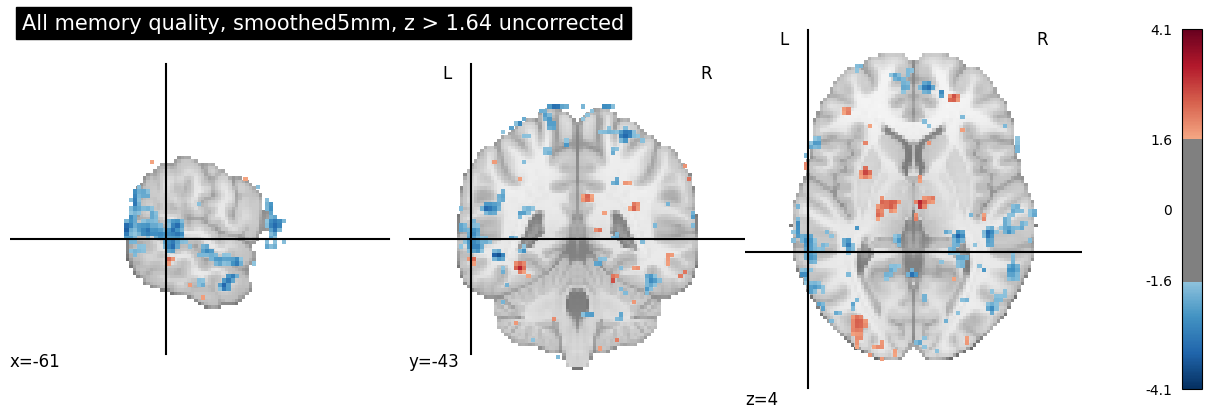

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_all_memory_quality_positive_smoothed5mm_zgt1.64.png


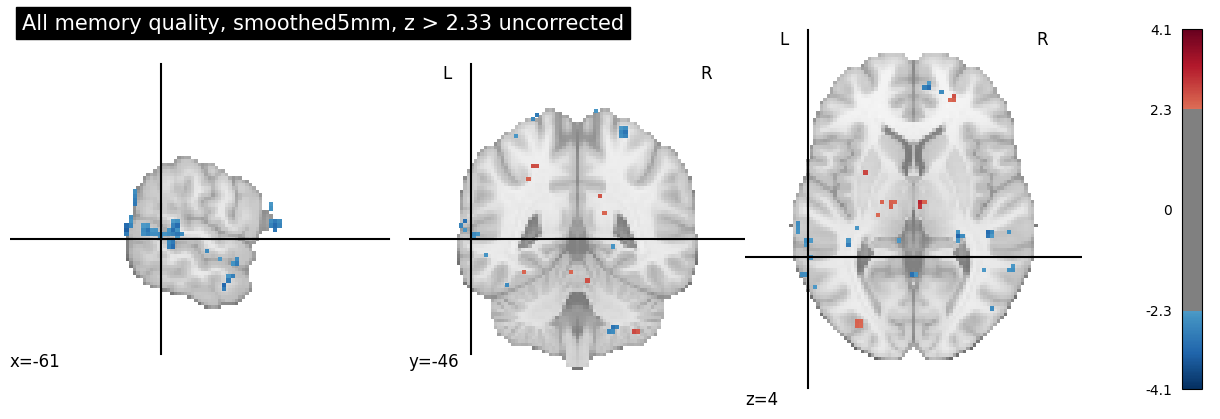

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_all_memory_quality_positive_smoothed5mm_zgt2.33.png


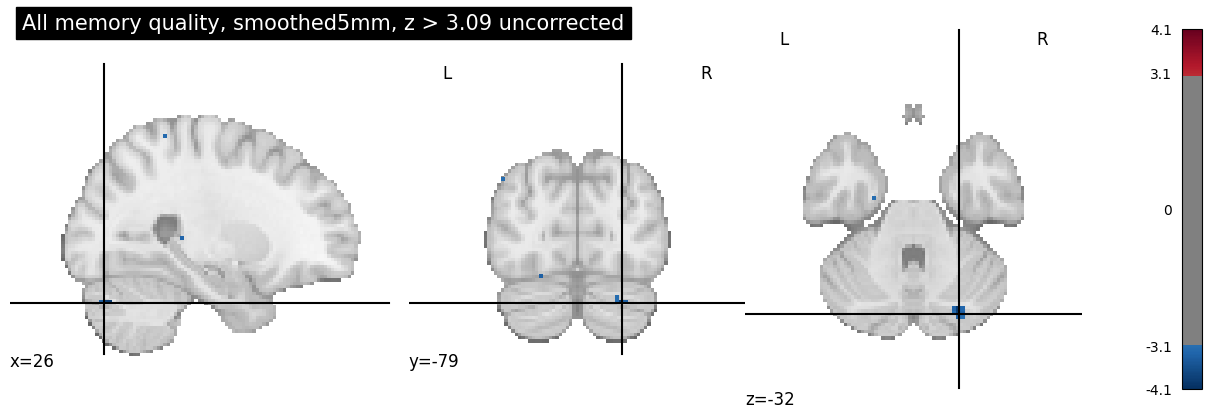

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_all_memory_quality_positive_smoothed5mm_zgt3.09.png


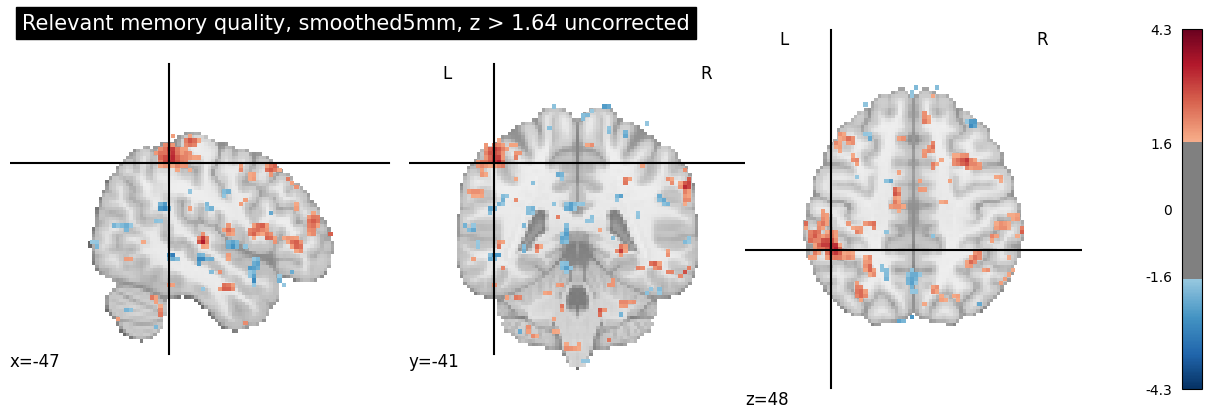

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_relevant_memory_quality_positive_smoothed5mm_zgt1.64.png


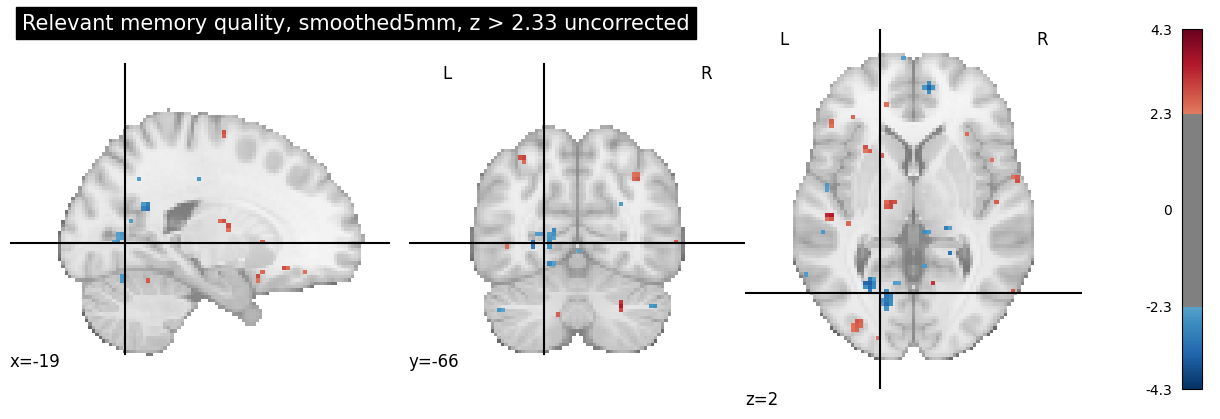

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_relevant_memory_quality_positive_smoothed5mm_zgt2.33.png


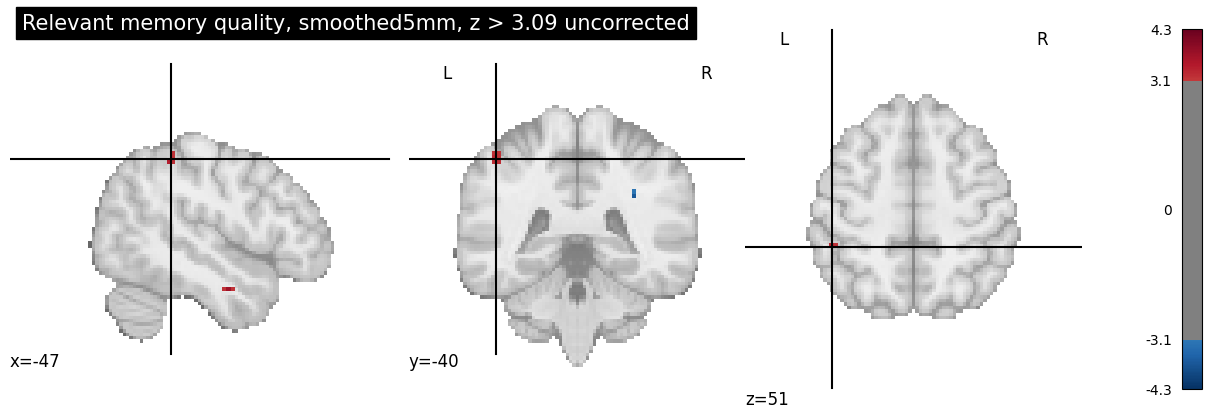

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_relevant_memory_quality_positive_smoothed5mm_zgt3.09.png


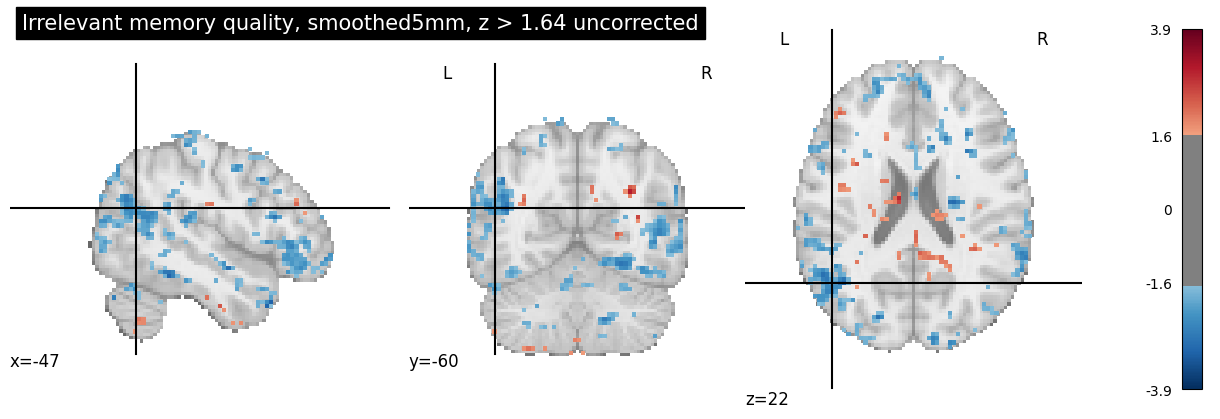

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_irrelevant_memory_quality_positive_smoothed5mm_zgt1.64.png


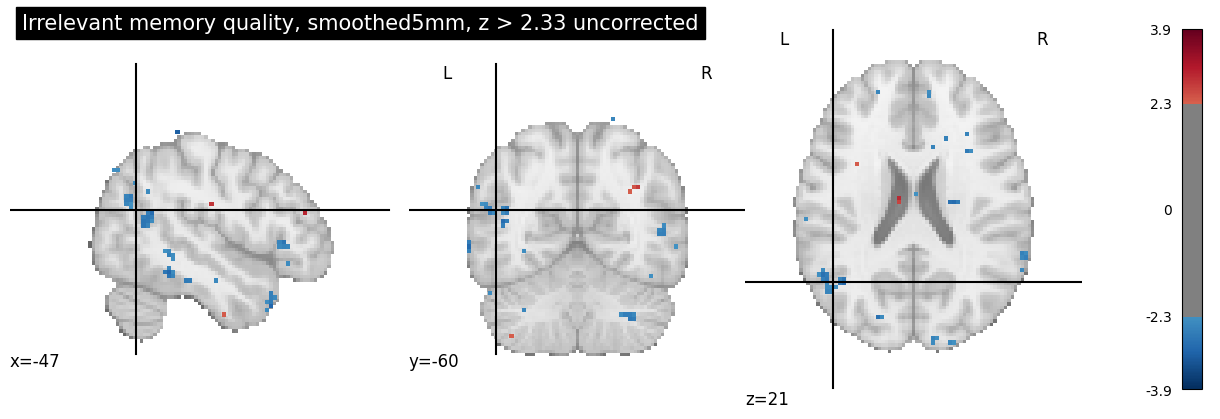

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_irrelevant_memory_quality_positive_smoothed5mm_zgt2.33.png


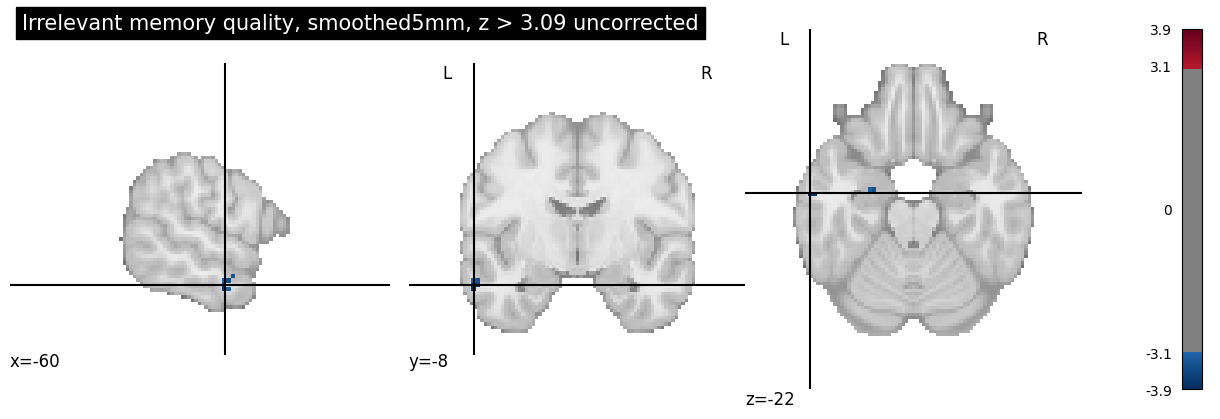

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_irrelevant_memory_quality_positive_smoothed5mm_zgt3.09.png


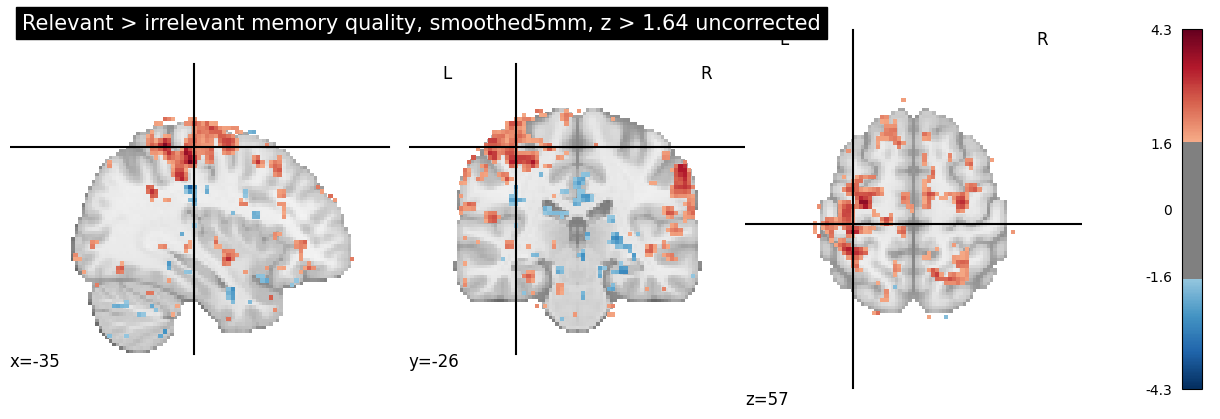

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_relevant_gt_irrelevant_memory_quality_smoothed5mm_zgt1.64.png


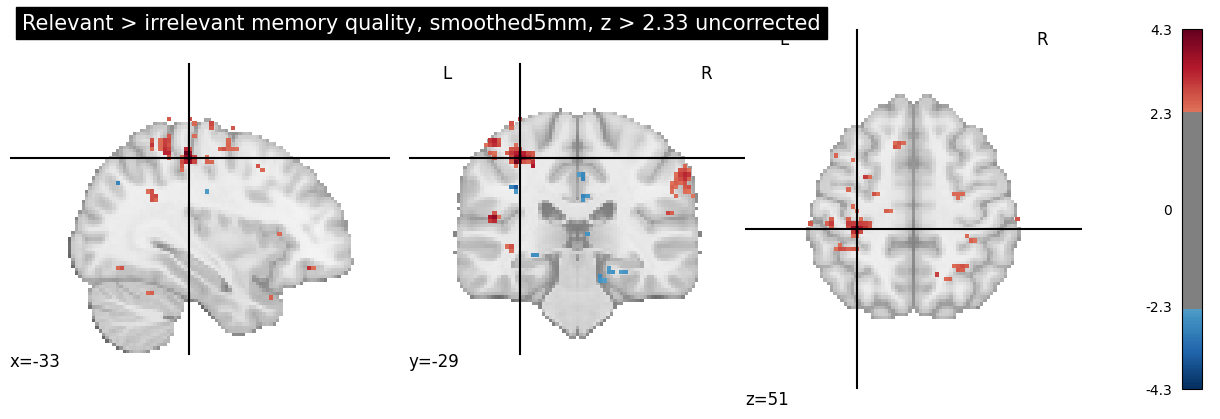

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_relevant_gt_irrelevant_memory_quality_smoothed5mm_zgt2.33.png


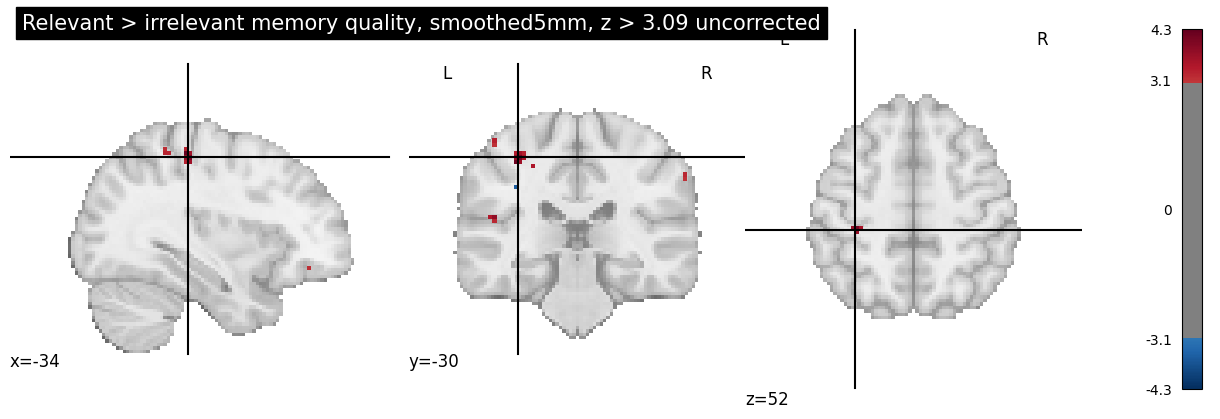

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_relevant_gt_irrelevant_memory_quality_smoothed5mm_zgt3.09.png


In [4]:
# ============================================================
# 3. Plot group maps at exploratory uncorrected thresholds
# ============================================================

EXPLORATORY_THRESHOLDS = [1.64, 2.33, 3.09]

for contrast_name in PRIMARY_CONTRASTS:
    z_map_path = get_group_z_map(contrast_name)
    z_img = nib.load(str(z_map_path))
    
    for threshold in EXPLORATORY_THRESHOLDS:
        fig = plt.figure(figsize=(12, 4))
        
        stat_display = plot_stat_map(
            z_img,
            threshold=threshold,
            display_mode="ortho",
            cut_coords=None,
            title=(
                f"{CONTRAST_LABELS[contrast_name]}, "
                f"{SMOOTHING_LABEL}, z > {threshold} uncorrected"
            ),
            figure=fig,
        )
        
        out_path = (
            WHOLE_BRAIN_FIG_DIR
            / f"group_{contrast_name}_{SMOOTHING_LABEL}_zgt{threshold}.png"
        )
        
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        
        print("Saved:", out_path)

In [5]:
# ============================================================
# 4. Robust cluster tables at multiple exploratory thresholds
# ============================================================

CLUSTER_THRESHOLDS = [1.64, 2.33, 3.09]
CLUSTER_EXTENT_VOXELS = 10
MIN_DISTANCE = 8

all_cluster_tables = []
cluster_summary_rows = []

def clean_and_filter_cluster_table(cluster_table, min_cluster_size_mm3=None):
    """
    Robustly clean Nilearn cluster tables.
    
    Nilearn writes cluster sizes only on main cluster rows.
    Sub-peaks such as 1a, 1b often have empty cluster-size cells.
    This function:
        - converts cluster size to numeric,
        - identifies the parent cluster ID,
        - propagates the main cluster size to sub-peaks,
        - optionally filters by cluster size.
    """
    if cluster_table is None or len(cluster_table) == 0:
        return pd.DataFrame()
    
    table = cluster_table.copy()
    
    # Make sure cluster IDs are strings.
    table["Cluster ID"] = table["Cluster ID"].astype(str)
    
    # Parent cluster: "1a" -> "1", "12b" -> "12".
    table["Parent Cluster ID"] = (
        table["Cluster ID"]
        .str.extract(r"^(\d+)", expand=False)
    )
    
    # Convert cluster size to numeric. Empty strings become NaN.
    table["Cluster Size (mm3)"] = pd.to_numeric(
        table["Cluster Size (mm3)"],
        errors="coerce",
    )
    
    # Parent cluster sizes are available on the main cluster rows.
    parent_sizes = (
        table
        .dropna(subset=["Cluster Size (mm3)"])
        .drop_duplicates(subset=["Parent Cluster ID"])
        .set_index("Parent Cluster ID")["Cluster Size (mm3)"]
        .to_dict()
    )
    
    table["Parent Cluster Size (mm3)"] = (
        table["Parent Cluster ID"]
        .map(parent_sizes)
    )
    
    if min_cluster_size_mm3 is not None:
        table = table.loc[
            table["Parent Cluster Size (mm3)"] >= min_cluster_size_mm3
        ].copy()
    
    return table


for contrast_name in PRIMARY_CONTRASTS:
    z_img = nib.load(str(get_group_z_map(contrast_name)))
    
    for z_threshold in CLUSTER_THRESHOLDS:
        try:
            # Important: use cluster_threshold=0 to avoid Nilearn string/int bug.
            raw_cluster_table = get_clusters_table(
                stat_img=z_img,
                stat_threshold=z_threshold,
                cluster_threshold=0,
                min_distance=MIN_DISTANCE,
            )
            
            # Approximate cluster extent filtering in mm3.
            # Your group maps have voxel volume around 15.625 mm3
            # because 10 voxels previously corresponded to about 156 mm3.
            voxel_volume_mm3 = abs(np.linalg.det(z_img.affine[:3, :3]))
            min_cluster_size_mm3 = CLUSTER_EXTENT_VOXELS * voxel_volume_mm3
            
            cluster_table = clean_and_filter_cluster_table(
                raw_cluster_table,
                min_cluster_size_mm3=min_cluster_size_mm3,
            )
            
            cluster_table["contrast"] = contrast_name
            cluster_table["contrast_label"] = CONTRAST_LABELS[contrast_name]
            cluster_table["z_threshold"] = z_threshold
            cluster_table["cluster_extent_threshold_voxels"] = CLUSTER_EXTENT_VOXELS
            cluster_table["cluster_extent_threshold_mm3"] = min_cluster_size_mm3
            cluster_table["first_level_smoothing_fwhm_mm"] = SMOOTHING_FWHM
            
            table_path = (
                WHOLE_BRAIN_TABLE_DIR
                / f"cluster_table_{contrast_name}_z{z_threshold}_k{CLUSTER_EXTENT_VOXELS}_robust.csv"
            )
            cluster_table.to_csv(table_path, index=False)
            
            all_cluster_tables.append(cluster_table)
            
            cluster_summary_rows.append({
                "contrast": contrast_name,
                "contrast_label": CONTRAST_LABELS[contrast_name],
                "z_threshold": z_threshold,
                "cluster_extent_threshold_voxels": CLUSTER_EXTENT_VOXELS,
                "cluster_extent_threshold_mm3": min_cluster_size_mm3,
                "n_rows": len(cluster_table),
                "n_parent_clusters": cluster_table["Parent Cluster ID"].nunique() if len(cluster_table) > 0 else 0,
                "max_peak_stat": cluster_table["Peak Stat"].max() if len(cluster_table) > 0 else np.nan,
                "largest_cluster_mm3": cluster_table["Parent Cluster Size (mm3)"].max() if len(cluster_table) > 0 else np.nan,
                "table_path": str(table_path),
            })
            
            print("\n" + "=" * 80)
            print(
                f"{CONTRAST_LABELS[contrast_name]} | "
                f"z > {z_threshold}, k >= {CLUSTER_EXTENT_VOXELS} voxels"
            )
            display(cluster_table.head(20))
            
        except Exception as exc:
            print(f"Failed for {contrast_name}, z > {z_threshold}: {exc}")
            cluster_summary_rows.append({
                "contrast": contrast_name,
                "contrast_label": CONTRAST_LABELS[contrast_name],
                "z_threshold": z_threshold,
                "cluster_extent_threshold_voxels": CLUSTER_EXTENT_VOXELS,
                "n_rows": np.nan,
                "n_parent_clusters": np.nan,
                "max_peak_stat": np.nan,
                "largest_cluster_mm3": np.nan,
                "table_path": None,
                "error": str(exc),
            })

cluster_summary = pd.DataFrame(cluster_summary_rows)

if len(all_cluster_tables) > 0:
    all_clusters = pd.concat(
        [table for table in all_cluster_tables if len(table) > 0],
        ignore_index=True,
    )
else:
    all_clusters = pd.DataFrame()

cluster_summary_path = WHOLE_BRAIN_TABLE_DIR / "cluster_summary_all_contrasts_thresholds_robust.csv"
all_clusters_path = WHOLE_BRAIN_TABLE_DIR / "all_cluster_tables_all_contrasts_thresholds_robust.csv"

cluster_summary.to_csv(cluster_summary_path, index=False)
all_clusters.to_csv(all_clusters_path, index=False)

print("\nCluster summary:")
display(cluster_summary)

print("\nSaved:")
print(cluster_summary_path)
print(all_clusters_path)


All memory quality | z > 1.64, k >= 10 voxels


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),Parent Cluster ID,Parent Cluster Size (mm3),contrast,contrast_label,z_threshold,cluster_extent_threshold_voxels,cluster_extent_threshold_mm3,first_level_smoothing_fwhm_mm
0,1,24.0,-52.0,17.0,4.098630,484.0,1,484.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0
1,2,51.5,-37.0,34.5,3.720205,296.0,2,296.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0
2,2a,51.5,-37.0,44.5,1.991688,NaN,2,296.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0
3,3,6.5,-27.0,27.0,3.637435,1890.0,3,1890.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0
4,3a,6.5,-12.0,29.5,2.841997,NaN,3,1890.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0
5,3b,1.5,-32.0,22.0,2.491246,NaN,3,1890.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0
6,3c,6.5,-42.0,29.5,2.387522,NaN,3,1890.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0
7,4,-38.5,-52.0,39.5,3.622403,1437.0,4,1437.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0
8,4a,-26.0,-47.0,47.0,2.673870,NaN,4,1437.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0
9,4b,-38.5,-62.0,49.5,1.922677,NaN,4,1437.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0



All memory quality | z > 2.33, k >= 10 voxels


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),Parent Cluster ID,Parent Cluster Size (mm3),contrast,contrast_label,z_threshold,cluster_extent_threshold_voxels,cluster_extent_threshold_mm3,first_level_smoothing_fwhm_mm
2,3,6.5,-27.0,27.0,3.637435,281.0,3,281.0,all_memory_quality_positive,All memory quality,2.33,10,156.25,5.0
3,4,-38.5,-52.0,39.5,3.622403,296.0,4,296.0,all_memory_quality_positive,All memory quality,2.33,10,156.25,5.0
5,6,46.5,-32.0,-8.0,3.588984,218.0,6,218.0,all_memory_quality_positive,All memory quality,2.33,10,156.25,5.0
6,7,16.5,-22.0,9.5,3.539212,281.0,7,281.0,all_memory_quality_positive,All memory quality,2.33,10,156.25,5.0
7,8,-13.5,-14.5,-0.5,3.493516,296.0,8,296.0,all_memory_quality_positive,All memory quality,2.33,10,156.25,5.0
17,18,26.5,3.0,-8.0,2.956750,296.0,18,296.0,all_memory_quality_positive,All memory quality,2.33,10,156.25,5.0
18,18a,31.5,3.0,-0.5,2.797085,NaN,18,296.0,all_memory_quality_positive,All memory quality,2.33,10,156.25,5.0
23,23,-28.5,3.0,7.0,2.875363,171.0,23,171.0,all_memory_quality_positive,All memory quality,2.33,10,156.25,5.0



All memory quality | z > 3.09, k >= 10 voxels


...


Relevant > irrelevant memory quality | z > 3.09, k >= 10 voxels


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),Parent Cluster ID,Parent Cluster Size (mm3),contrast,contrast_label,z_threshold,cluster_extent_threshold_voxels,cluster_extent_threshold_mm3,first_level_smoothing_fwhm_mm
0,1,-33.5,-32.0,54.5,4.268709,281,1,281,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,3.09,10,156.25,5.0
2,3,-36.0,-44.5,59.5,3.922052,171,3,171,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,3.09,10,156.25,5.0
23,24,61.5,-27.0,47.0,3.449916,187,24,187,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,3.09,10,156.25,5.0



Cluster summary:


,contrast,contrast_label,z_threshold,cluster_extent_threshold_voxels,cluster_extent_threshold_mm3,n_rows,n_parent_clusters,max_peak_stat,largest_cluster_mm3,table_path
0,all_memory_quality_positive,All memory quality,1.64,10,156.25,81,50,4.098630,1890.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,all_memory_quality_positive,All memory quality,2.33,10,156.25,8,7,3.637435,296.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,all_memory_quality_positive,All memory quality,3.09,10,156.25,0,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,relevant_memory_quality_positive,Relevant memory quality,1.64,10,156.25,177,99,4.343043,9640.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,relevant_memory_quality_positive,Relevant memory quality,2.33,10,156.25,15,13,3.944574,1031.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
5,relevant_memory_quality_positive,Relevant memory quality,3.09,10,156.25,0,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
6,irrelevant_memory_quality_positive,Irrelevant memory quality,1.64,10,156.25,66,41,3.857708,4015.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
7,irrelevant_memory_quality_positive,Irrelevant memory quality,2.33,10,156.25,3,3,3.513207,375.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
8,irrelevant_memory_quality_positive,Irrelevant memory quality,3.09,10,156.25,0,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
9,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,1.64,10,156.25,225,124,4.268709,34359.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/cluster_summary_all_contrasts_thresholds_robust.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/all_cluster_tables_all_contrasts_thresholds_robust.csv


In [6]:
# ============================================================
# 5. Focused summary: relevant > irrelevant memory-quality contrast
# ============================================================

interaction_contrast = "relevant_gt_irrelevant_memory_quality"

interaction_clusters = all_clusters.loc[
    all_clusters["contrast"] == interaction_contrast
].copy()

interaction_clusters_interpretable = interaction_clusters.loc[
    interaction_clusters["z_threshold"].isin([2.33, 3.09])
].copy()

interaction_clusters_interpretable = interaction_clusters_interpretable.sort_values(
    ["z_threshold", "Peak Stat"],
    ascending=[True, False],
)

print("Focused interaction clusters:")
display(interaction_clusters_interpretable)

interaction_clusters_path = (
    WHOLE_BRAIN_TABLE_DIR
    / "focused_interaction_relevant_gt_irrelevant_clusters_robust.csv"
)
interaction_clusters_interpretable.to_csv(interaction_clusters_path, index=False)

print("Saved:")
print(interaction_clusters_path)

print("\nTop interaction clusters at z > 2.33:")
display(
    interaction_clusters_interpretable
    .loc[interaction_clusters_interpretable["z_threshold"] == 2.33]
    .head(15)
)

print("\nTop interaction clusters at z > 3.09:")
display(
    interaction_clusters_interpretable
    .loc[interaction_clusters_interpretable["z_threshold"] == 3.09]
    .head(15)
)

Focused interaction clusters:


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),Parent Cluster ID,Parent Cluster Size (mm3),contrast,contrast_label,z_threshold,cluster_extent_threshold_voxels,cluster_extent_threshold_mm3,first_level_smoothing_fwhm_mm
575,1,-33.5,-32.0,54.5,4.268709,3531.0,1,3531.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
579,2,26.5,5.5,-23.0,4.127168,421.0,2,421.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
580,3,-36.0,-44.5,59.5,3.922052,1390.0,3,1390.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
583,4,-41.0,-62.0,19.5,3.910846,359.0,4,359.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
576,1a,-28.5,-14.5,59.5,3.908293,NaN,1,3531.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
584,5,-48.5,-29.5,17.0,3.794616,187.0,5,187.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
585,7,6.5,15.5,62.0,3.618838,187.0,7,187.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
577,1b,-38.5,-12.0,64.5,3.608744,NaN,1,3531.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
586,8,-28.5,0.5,-13.0,3.608170,187.0,8,187.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
587,9,21.5,28.0,9.5,3.574386,328.0,9,328.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/focused_interaction_relevant_gt_irrelevant_clusters_robust.csv

Top interaction clusters at z > 2.33:


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),Parent Cluster ID,Parent Cluster Size (mm3),contrast,contrast_label,z_threshold,cluster_extent_threshold_voxels,cluster_extent_threshold_mm3,first_level_smoothing_fwhm_mm
575,1,-33.5,-32.0,54.5,4.268709,3531.0,1,3531.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
579,2,26.5,5.5,-23.0,4.127168,421.0,2,421.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
580,3,-36.0,-44.5,59.5,3.922052,1390.0,3,1390.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
583,4,-41.0,-62.0,19.5,3.910846,359.0,4,359.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
576,1a,-28.5,-14.5,59.5,3.908293,NaN,1,3531.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
584,5,-48.5,-29.5,17.0,3.794616,187.0,5,187.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
585,7,6.5,15.5,62.0,3.618838,187.0,7,187.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
577,1b,-38.5,-12.0,64.5,3.608744,NaN,1,3531.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
586,8,-28.5,0.5,-13.0,3.608170,187.0,8,187.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
587,9,21.5,28.0,9.5,3.574386,328.0,9,328.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0



Top interaction clusters at z > 3.09:


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),Parent Cluster ID,Parent Cluster Size (mm3),contrast,contrast_label,z_threshold,cluster_extent_threshold_voxels,cluster_extent_threshold_mm3,first_level_smoothing_fwhm_mm
627,1,-33.5,-32.0,54.5,4.268709,281.0,1,281.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,3.09,10,156.25,5.0
628,3,-36.0,-44.5,59.5,3.922052,171.0,3,171.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,3.09,10,156.25,5.0
629,24,61.5,-27.0,47.0,3.449916,187.0,24,187.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,3.09,10,156.25,5.0


In [7]:
# ============================================================
# 7. Create report-ready parent-cluster tables
# ============================================================

# Keep only main parent-cluster rows, not sub-peaks like 1a, 1b.
# Parent rows have Cluster ID equal to Parent Cluster ID.

all_clusters_clean = all_clusters.copy()

all_clusters_clean["Cluster ID"] = all_clusters_clean["Cluster ID"].astype(str)
all_clusters_clean["Parent Cluster ID"] = all_clusters_clean["Parent Cluster ID"].astype(str)

parent_clusters = all_clusters_clean.loc[
    all_clusters_clean["Cluster ID"] == all_clusters_clean["Parent Cluster ID"]
].copy()

parent_clusters = parent_clusters.sort_values(
    ["contrast", "z_threshold", "Peak Stat"],
    ascending=[True, True, False],
)

parent_clusters_path = WHOLE_BRAIN_TABLE_DIR / "parent_clusters_all_contrasts_thresholds.csv"
parent_clusters.to_csv(parent_clusters_path, index=False)

print("Parent-cluster table:")
display(parent_clusters)

print("Saved:")
print(parent_clusters_path)

# Focused interaction parent clusters
interaction_parent_clusters = parent_clusters.loc[
    parent_clusters["contrast"] == "relevant_gt_irrelevant_memory_quality"
].copy()

interaction_parent_clusters_path = (
    WHOLE_BRAIN_TABLE_DIR
    / "parent_clusters_interaction_relevant_gt_irrelevant.csv"
)
interaction_parent_clusters.to_csv(interaction_parent_clusters_path, index=False)

print("\nInteraction parent clusters:")
display(interaction_parent_clusters)

print("Saved:")
print(interaction_parent_clusters_path)

Parent-cluster table:


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),Parent Cluster ID,Parent Cluster Size (mm3),contrast,contrast_label,z_threshold,cluster_extent_threshold_voxels,cluster_extent_threshold_mm3,first_level_smoothing_fwhm_mm
0,1,24.0,-52.0,17.0,4.098630,484.0,1,484.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0
1,2,51.5,-37.0,34.5,3.720205,296.0,2,296.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0
3,3,6.5,-27.0,27.0,3.637435,1890.0,3,1890.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0
7,4,-38.5,-52.0,39.5,3.622403,1437.0,4,1437.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0
10,5,11.5,15.5,-13.0,3.590479,359.0,5,359.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,20,-38.5,-52.0,42.0,3.228171,328.0,20,328.0,relevant_memory_quality_positive,Relevant memory quality,2.33,10,156.25,5.0
277,22,-23.5,-7.0,17.0,3.211410,187.0,22,187.0,relevant_memory_quality_positive,Relevant memory quality,2.33,10,156.25,5.0
278,28,-21.0,38.0,-15.5,3.103406,312.0,28,312.0,relevant_memory_quality_positive,Relevant memory quality,2.33,10,156.25,5.0
279,42,-61.0,5.5,27.0,2.914419,171.0,42,171.0,relevant_memory_quality_positive,Relevant memory quality,2.33,10,156.25,5.0


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/parent_clusters_all_contrasts_thresholds.csv

Interaction parent clusters:


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),Parent Cluster ID,Parent Cluster Size (mm3),contrast,contrast_label,z_threshold,cluster_extent_threshold_voxels,cluster_extent_threshold_mm3,first_level_smoothing_fwhm_mm
350,1,-33.5,-32.0,54.5,4.268709,34359.0,1,34359.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,1.64,10,156.25,5.0
354,2,26.5,5.5,-23.0,4.127168,1078.0,2,1078.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,1.64,10,156.25,5.0
355,3,-41.0,-62.0,19.5,3.910846,3703.0,3,3703.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,1.64,10,156.25,5.0
359,4,-48.5,-29.5,17.0,3.794616,828.0,4,828.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,1.64,10,156.25,5.0
362,5,-28.5,0.5,-13.0,3.608170,609.0,5,609.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,1.64,10,156.25,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,106,46.5,13.0,7.0,2.756183,171.0,106,171.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
625,125,-11.0,18.0,52.0,2.701920,171.0,125,171.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,2.33,10,156.25,5.0
627,1,-33.5,-32.0,54.5,4.268709,281.0,1,281.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,3.09,10,156.25,5.0
628,3,-36.0,-44.5,59.5,3.922052,171.0,3,171.0,relevant_gt_irrelevant_memory_quality,Relevant > irrelevant memory quality,3.09,10,156.25,5.0


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/parent_clusters_interaction_relevant_gt_irrelevant.csv


In [8]:
# ============================================================
# 8. Label peaks using Harvard-Oxford cortical and subcortical atlases
# ============================================================

import xml.etree.ElementTree as ET
from nilearn.image import resample_to_img, coord_transform

HO_ATLAS_DIR = Path.home() / "nilearn_data" / "fsl" / "data" / "atlases"

HO_CORT_ATLAS_PATH = HO_ATLAS_DIR / "HarvardOxford" / "HarvardOxford-cort-maxprob-thr25-2mm.nii.gz"
HO_CORT_XML_PATH = HO_ATLAS_DIR / "HarvardOxford-Cortical.xml"

HO_SUB_ATLAS_PATH = HO_ATLAS_DIR / "HarvardOxford" / "HarvardOxford-sub-maxprob-thr25-2mm.nii.gz"
HO_SUB_XML_PATH = HO_ATLAS_DIR / "HarvardOxford-Subcortical.xml"

print("Cortical atlas exists:", HO_CORT_ATLAS_PATH.exists())
print("Cortical XML exists:", HO_CORT_XML_PATH.exists())
print("Subcortical atlas exists:", HO_SUB_ATLAS_PATH.exists())
print("Subcortical XML exists:", HO_SUB_XML_PATH.exists())

assert HO_CORT_ATLAS_PATH.exists()
assert HO_CORT_XML_PATH.exists()
assert HO_SUB_ATLAS_PATH.exists()
assert HO_SUB_XML_PATH.exists()


def parse_fsl_xml_labels(xml_path):
    """
    Parse FSL-style atlas XML.
    For Harvard-Oxford maxprob images, label image value is usually XML index + 1.
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    rows = []
    for label in root.iter("label"):
        xml_index = int(label.attrib["index"])
        rows.append({
            "xml_index": xml_index,
            "atlas_value": xml_index + 1,
            "label": label.text,
        })
    
    return pd.DataFrame(rows)


ho_cort_labels = parse_fsl_xml_labels(HO_CORT_XML_PATH)
ho_sub_labels = parse_fsl_xml_labels(HO_SUB_XML_PATH)

print("\nExample cortical labels:")
display(ho_cort_labels.head())

print("\nExample subcortical labels:")
display(ho_sub_labels.head())


# Use one group z-map as target image/grid.
reference_group_img = nib.load(str(get_group_z_map("relevant_gt_irrelevant_memory_quality")))

ho_cort_img = nib.load(str(HO_CORT_ATLAS_PATH))
ho_sub_img = nib.load(str(HO_SUB_ATLAS_PATH))

ho_cort_resampled = resample_to_img(
    source_img=ho_cort_img,
    target_img=reference_group_img,
    interpolation="nearest",
    force_resample=True,
    copy_header=True,
)

ho_sub_resampled = resample_to_img(
    source_img=ho_sub_img,
    target_img=reference_group_img,
    interpolation="nearest",
    force_resample=True,
    copy_header=True,
)

ho_cort_data = ho_cort_resampled.get_fdata()
ho_sub_data = ho_sub_resampled.get_fdata()

inv_affine = np.linalg.inv(reference_group_img.affine)


def get_atlas_label_at_coord(x, y, z, atlas_data, labels_df):
    """
    Return atlas value and label at MNI coordinate.
    """
    i, j, k = coord_transform(x, y, z, inv_affine)
    i, j, k = int(round(i)), int(round(j)), int(round(k))
    
    if (
        i < 0 or i >= atlas_data.shape[0]
        or j < 0 or j >= atlas_data.shape[1]
        or k < 0 or k >= atlas_data.shape[2]
    ):
        return 0, "outside atlas"
    
    atlas_value = int(round(atlas_data[i, j, k]))
    
    if atlas_value == 0:
        return atlas_value, "no label"
    
    label_match = labels_df.loc[
        labels_df["atlas_value"] == atlas_value,
        "label",
    ]
    
    if len(label_match) == 0:
        return atlas_value, "unknown label"
    
    return atlas_value, label_match.iloc[0]


# Label all parent clusters.
labeled_rows = []

for _, row in parent_clusters.iterrows():
    x, y, z = float(row["X"]), float(row["Y"]), float(row["Z"])
    
    cort_value, cort_label = get_atlas_label_at_coord(
        x, y, z,
        ho_cort_data,
        ho_cort_labels,
    )
    
    sub_value, sub_label = get_atlas_label_at_coord(
        x, y, z,
        ho_sub_data,
        ho_sub_labels,
    )
    
    labeled_row = row.to_dict()
    labeled_row.update({
        "HO_cortical_value": cort_value,
        "HO_cortical_label": cort_label,
        "HO_subcortical_value": sub_value,
        "HO_subcortical_label": sub_label,
    })
    
    # Prefer cortical label if present, otherwise subcortical.
    if cort_label != "no label":
        best_label = cort_label
        best_label_source = "Harvard-Oxford cortical"
    elif sub_label != "no label":
        best_label = sub_label
        best_label_source = "Harvard-Oxford subcortical"
    else:
        best_label = "no Harvard-Oxford label at peak"
        best_label_source = "none"
    
    labeled_row.update({
        "best_HO_label": best_label,
        "best_HO_label_source": best_label_source,
    })
    
    labeled_rows.append(labeled_row)

parent_clusters_labeled = pd.DataFrame(labeled_rows)

parent_clusters_labeled_path = (
    WHOLE_BRAIN_TABLE_DIR
    / "parent_clusters_all_contrasts_thresholds_harvard_oxford_labeled.csv"
)
parent_clusters_labeled.to_csv(parent_clusters_labeled_path, index=False)

print("Labeled parent clusters:")
display(parent_clusters_labeled)

print("Saved:")
print(parent_clusters_labeled_path)

Cortical atlas exists: True
Cortical XML exists: True
Subcortical atlas exists: True
Subcortical XML exists: True

Example cortical labels:


,xml_index,atlas_value,label
0,0,1,Frontal Pole
1,1,2,Insular Cortex
2,2,3,Superior Frontal Gyrus
3,3,4,Middle Frontal Gyrus
4,4,5,"Inferior Frontal Gyrus, pars triangularis"



Example subcortical labels:


,xml_index,atlas_value,label
0,0,1,Left Cerebral White Matter
1,1,2,Left Cerebral Cortex
2,2,3,Left Lateral Ventrical
3,3,4,Left Thalamus
4,4,5,Left Caudate


Labeled parent clusters:


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),Parent Cluster ID,Parent Cluster Size (mm3),contrast,contrast_label,z_threshold,cluster_extent_threshold_voxels,cluster_extent_threshold_mm3,first_level_smoothing_fwhm_mm,HO_cortical_value,HO_cortical_label,HO_subcortical_value,HO_subcortical_label,best_HO_label,best_HO_label_source
0,1,24.0,-52.0,17.0,4.098630,484.0,1,484.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0,0,no label,12,Right Cerebral White Matter,Right Cerebral White Matter,Harvard-Oxford subcortical
1,2,51.5,-37.0,34.5,3.720205,296.0,2,296.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0,0,no label,12,Right Cerebral White Matter,Right Cerebral White Matter,Harvard-Oxford subcortical
2,3,6.5,-27.0,27.0,3.637435,1890.0,3,1890.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0,30,"Cingulate Gyrus, posterior division",13,Right Cerebral Cortex,"Cingulate Gyrus, posterior division",Harvard-Oxford cortical
3,4,-38.5,-52.0,39.5,3.622403,1437.0,4,1437.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0,0,no label,1,Left Cerebral White Matter,Left Cerebral White Matter,Harvard-Oxford subcortical
4,5,11.5,15.5,-13.0,3.590479,359.0,5,359.0,all_memory_quality_positive,All memory quality,1.64,10,156.25,5.0,27,Subcallosal Cortex,12,Right Cerebral White Matter,Subcallosal Cortex,Harvard-Oxford cortical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,20,-38.5,-52.0,42.0,3.228171,328.0,20,328.0,relevant_memory_quality_positive,Relevant memory quality,2.33,10,156.25,5.0,0,no label,2,Left Cerebral Cortex,Left Cerebral Cortex,Harvard-Oxford subcortical
369,22,-23.5,-7.0,17.0,3.211410,187.0,22,187.0,relevant_memory_quality_positive,Relevant memory quality,2.33,10,156.25,5.0,0,no label,1,Left Cerebral White Matter,Left Cerebral White Matter,Harvard-Oxford subcortical
370,28,-21.0,38.0,-15.5,3.103406,312.0,28,312.0,relevant_memory_quality_positive,Relevant memory quality,2.33,10,156.25,5.0,1,Frontal Pole,2,Left Cerebral Cortex,Frontal Pole,Harvard-Oxford cortical
371,42,-61.0,5.5,27.0,2.914419,171.0,42,171.0,relevant_memory_quality_positive,Relevant memory quality,2.33,10,156.25,5.0,7,Precentral Gyrus,2,Left Cerebral Cortex,Precentral Gyrus,Harvard-Oxford cortical


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/parent_clusters_all_contrasts_thresholds_harvard_oxford_labeled.csv


In [9]:
# ============================================================
# 9. Focused labeled table: relevant > irrelevant interaction
# ============================================================

interaction_parent_clusters_labeled = parent_clusters_labeled.loc[
    parent_clusters_labeled["contrast"] == "relevant_gt_irrelevant_memory_quality"
].copy()

interaction_parent_clusters_labeled = interaction_parent_clusters_labeled.sort_values(
    ["z_threshold", "Peak Stat"],
    ascending=[True, False],
)

# More compact table for reporting
interaction_report_table = interaction_parent_clusters_labeled[
    [
        "z_threshold",
        "Cluster ID",
        "X",
        "Y",
        "Z",
        "Peak Stat",
        "Parent Cluster Size (mm3)",
        "best_HO_label",
        "best_HO_label_source",
        "HO_cortical_label",
        "HO_subcortical_label",
    ]
].copy()

display(interaction_report_table)

interaction_report_table_path = (
    WHOLE_BRAIN_TABLE_DIR
    / "interaction_relevant_gt_irrelevant_parent_clusters_labeled_report_table.csv"
)
interaction_report_table.to_csv(interaction_report_table_path, index=False)

print("Saved:")
print(interaction_report_table_path)

print("\nStrict threshold z > 3.09:")
display(
    interaction_report_table
    .loc[interaction_report_table["z_threshold"] == 3.09]
)

print("\nExploratory threshold z > 2.33, top 15:")
display(
    interaction_report_table
    .loc[interaction_report_table["z_threshold"] == 2.33]
    .head(15)
)

,z_threshold,Cluster ID,X,Y,Z,Peak Stat,Parent Cluster Size (mm3),best_HO_label,best_HO_label_source,HO_cortical_label,HO_subcortical_label
101,1.64,1,-33.5,-32.0,54.5,4.268709,34359.0,Postcentral Gyrus,Harvard-Oxford cortical,Postcentral Gyrus,Left Cerebral Cortex
102,1.64,2,26.5,5.5,-23.0,4.127168,1078.0,Temporal Pole,Harvard-Oxford cortical,Temporal Pole,Right Cerebral Cortex
103,1.64,3,-41.0,-62.0,19.5,3.910846,3703.0,"Lateral Occipital Cortex, superior division",Harvard-Oxford cortical,"Lateral Occipital Cortex, superior division",Left Cerebral Cortex
104,1.64,4,-48.5,-29.5,17.0,3.794616,828.0,Parietal Operculum Cortex,Harvard-Oxford cortical,Parietal Operculum Cortex,Left Cerebral Cortex
105,1.64,5,-28.5,0.5,-13.0,3.608170,609.0,Left Cerebral White Matter,Harvard-Oxford subcortical,no label,Left Cerebral White Matter
...,...,...,...,...,...,...,...,...,...,...,...
256,2.33,106,46.5,13.0,7.0,2.756183,171.0,Frontal Operculum Cortex,Harvard-Oxford cortical,Frontal Operculum Cortex,Right Cerebral White Matter
257,2.33,125,-11.0,18.0,52.0,2.701920,171.0,Left Cerebral White Matter,Harvard-Oxford subcortical,no label,Left Cerebral White Matter
258,3.09,1,-33.5,-32.0,54.5,4.268709,281.0,Postcentral Gyrus,Harvard-Oxford cortical,Postcentral Gyrus,Left Cerebral Cortex
259,3.09,3,-36.0,-44.5,59.5,3.922052,171.0,Superior Parietal Lobule,Harvard-Oxford cortical,Superior Parietal Lobule,Left Cerebral Cortex


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/interaction_relevant_gt_irrelevant_parent_clusters_labeled_report_table.csv

Strict threshold z > 3.09:


,z_threshold,Cluster ID,X,Y,Z,Peak Stat,Parent Cluster Size (mm3),best_HO_label,best_HO_label_source,HO_cortical_label,HO_subcortical_label
258,3.09,1,-33.5,-32.0,54.5,4.268709,281.0,Postcentral Gyrus,Harvard-Oxford cortical,Postcentral Gyrus,Left Cerebral Cortex
259,3.09,3,-36.0,-44.5,59.5,3.922052,171.0,Superior Parietal Lobule,Harvard-Oxford cortical,Superior Parietal Lobule,Left Cerebral Cortex
260,3.09,24,61.5,-27.0,47.0,3.449916,187.0,"Supramarginal Gyrus, anterior division",Harvard-Oxford cortical,"Supramarginal Gyrus, anterior division",Right Cerebral Cortex



Exploratory threshold z > 2.33, top 15:


,z_threshold,Cluster ID,X,Y,Z,Peak Stat,Parent Cluster Size (mm3),best_HO_label,best_HO_label_source,HO_cortical_label,HO_subcortical_label
225,2.33,1,-33.5,-32.0,54.5,4.268709,3531.0,Postcentral Gyrus,Harvard-Oxford cortical,Postcentral Gyrus,Left Cerebral Cortex
226,2.33,2,26.5,5.5,-23.0,4.127168,421.0,Temporal Pole,Harvard-Oxford cortical,Temporal Pole,Right Cerebral Cortex
227,2.33,3,-36.0,-44.5,59.5,3.922052,1390.0,Superior Parietal Lobule,Harvard-Oxford cortical,Superior Parietal Lobule,Left Cerebral Cortex
228,2.33,4,-41.0,-62.0,19.5,3.910846,359.0,"Lateral Occipital Cortex, superior division",Harvard-Oxford cortical,"Lateral Occipital Cortex, superior division",Left Cerebral Cortex
229,2.33,5,-48.5,-29.5,17.0,3.794616,187.0,Parietal Operculum Cortex,Harvard-Oxford cortical,Parietal Operculum Cortex,Left Cerebral Cortex
230,2.33,7,6.5,15.5,62.0,3.618838,187.0,Superior Frontal Gyrus,Harvard-Oxford cortical,Superior Frontal Gyrus,Right Cerebral Cortex
231,2.33,8,-28.5,0.5,-13.0,3.608170,187.0,Left Cerebral White Matter,Harvard-Oxford subcortical,no label,Left Cerebral White Matter
232,2.33,9,21.5,28.0,9.5,3.574386,328.0,Right Cerebral White Matter,Harvard-Oxford subcortical,no label,Right Cerebral White Matter
233,2.33,11,51.5,3.0,34.5,3.530947,562.0,Precentral Gyrus,Harvard-Oxford cortical,Precentral Gyrus,Right Cerebral Cortex
234,2.33,12,-28.5,18.0,4.5,3.516766,265.0,Left Cerebral White Matter,Harvard-Oxford subcortical,no label,Left Cerebral White Matter


,X,Y,Z,Peak Stat,best_HO_label
258,-33.5,-32.0,54.5,4.268709,Postcentral Gyrus
259,-36.0,-44.5,59.5,3.922052,Superior Parietal Lobule
260,61.5,-27.0,47.0,3.449916,"Supramarginal Gyrus, anterior division"


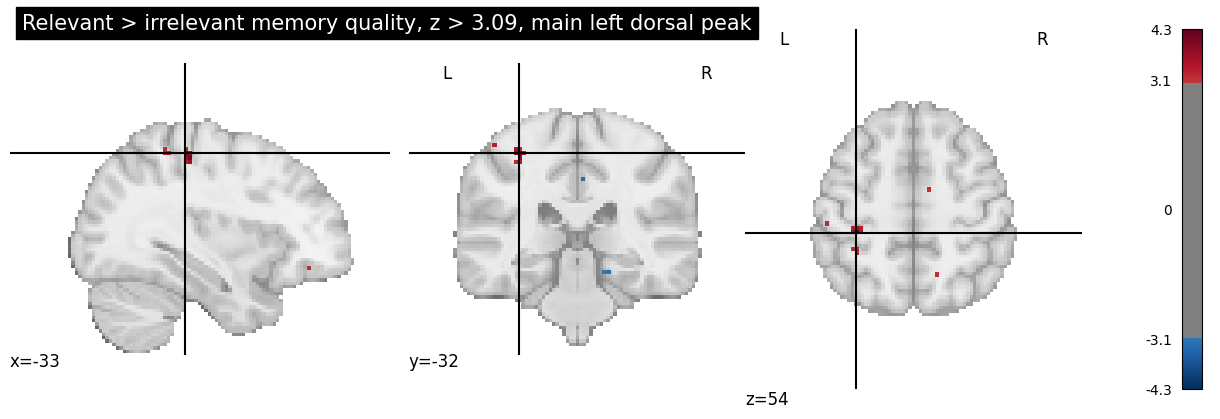

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/interaction_zgt3.09_main_left_dorsal_peak.png


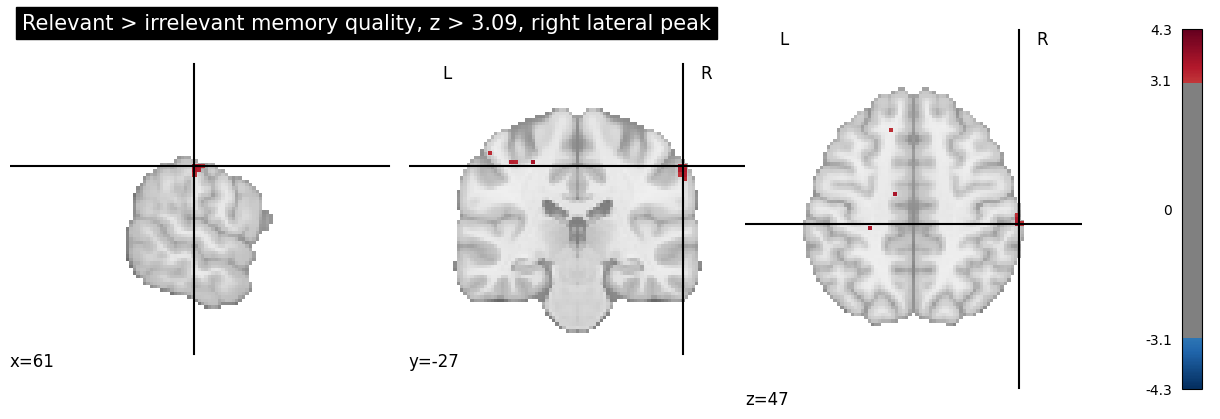

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/interaction_zgt3.09_right_lateral_peak.png


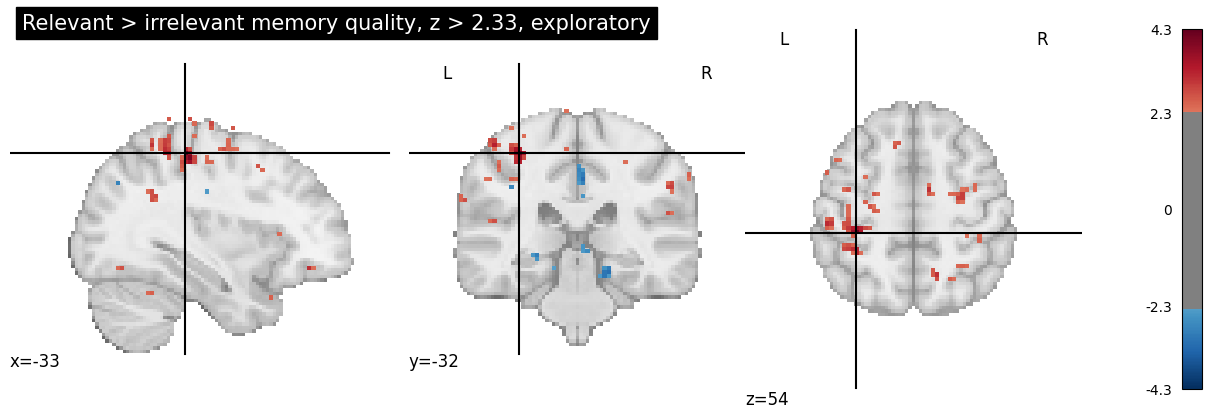

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/interaction_zgt2.33_main_left_dorsal_cluster.png


In [10]:
# ============================================================
# 10. Plot strict interaction clusters with selected cut coordinates
# ============================================================

interaction_contrast = "relevant_gt_irrelevant_memory_quality"
interaction_z_img = nib.load(str(get_group_z_map(interaction_contrast)))

# Cut coordinates from z > 3.09 peaks
strict_peaks = interaction_report_table.loc[
    interaction_report_table["z_threshold"] == 3.09,
    ["X", "Y", "Z", "Peak Stat", "best_HO_label"]
].copy()

display(strict_peaks)

# Plot around main left dorsal fronto-parietal peak
fig = plt.figure(figsize=(12, 4))

plot_stat_map(
    interaction_z_img,
    threshold=3.09,
    display_mode="ortho",
    cut_coords=(-33.5, -32.0, 54.5),
    title="Relevant > irrelevant memory quality, z > 3.09, main left dorsal peak",
    figure=fig,
)

out_path = WHOLE_BRAIN_FIG_DIR / "interaction_zgt3.09_main_left_dorsal_peak.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()
print("Saved:", out_path)


# Plot around right-lateral surviving peak
fig = plt.figure(figsize=(12, 4))

plot_stat_map(
    interaction_z_img,
    threshold=3.09,
    display_mode="ortho",
    cut_coords=(61.5, -27.0, 47.0),
    title="Relevant > irrelevant memory quality, z > 3.09, right lateral peak",
    figure=fig,
)

out_path = WHOLE_BRAIN_FIG_DIR / "interaction_zgt3.09_right_lateral_peak.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()
print("Saved:", out_path)


# Broader z > 2.33 view centered on the largest cluster
fig = plt.figure(figsize=(12, 4))

plot_stat_map(
    interaction_z_img,
    threshold=2.33,
    display_mode="ortho",
    cut_coords=(-33.5, -32.0, 54.5),
    title="Relevant > irrelevant memory quality, z > 2.33, exploratory",
    figure=fig,
)

out_path = WHOLE_BRAIN_FIG_DIR / "interaction_zgt2.33_main_left_dorsal_cluster.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()
print("Saved:", out_path)


Voxel-wise uncorrected p < .001, one-sided


Computed threshold: 3.090232306167813
Saved thresholded map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/maps/group_relevant_gt_irrelevant_memory_quality_smoothed5mm_fpr_p001_uncorrected.nii.gz


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),threshold_name,height_control,alpha,computed_z_threshold,contrast
0,1,-33.5,-32.0,54.5,4.268709,281,fpr_p001_uncorrected,fpr,0.001,3.090232,relevant_gt_irrelevant_memory_quality
1,2,26.5,5.5,-23.0,4.127168,15,fpr_p001_uncorrected,fpr,0.001,3.090232,relevant_gt_irrelevant_memory_quality
2,3,-36.0,-44.5,59.5,3.922052,171,fpr_p001_uncorrected,fpr,0.001,3.090232,relevant_gt_irrelevant_memory_quality
3,4,-41.0,-62.0,19.5,3.910846,109,fpr_p001_uncorrected,fpr,0.001,3.090232,relevant_gt_irrelevant_memory_quality
4,5,-28.5,-14.5,59.5,3.908293,125,fpr_p001_uncorrected,fpr,0.001,3.090232,relevant_gt_irrelevant_memory_quality
...,...,...,...,...,...,...,...,...,...,...,...
57,58,34.0,38.0,-5.5,3.110918,15,fpr_p001_uncorrected,fpr,0.001,3.090232,relevant_gt_irrelevant_memory_quality
58,59,26.5,3.0,-20.5,3.110678,15,fpr_p001_uncorrected,fpr,0.001,3.090232,relevant_gt_irrelevant_memory_quality
59,60,14.0,-57.0,54.5,3.106966,15,fpr_p001_uncorrected,fpr,0.001,3.090232,relevant_gt_irrelevant_memory_quality
60,61,49.0,38.0,-15.5,3.098645,15,fpr_p001_uncorrected,fpr,0.001,3.090232,relevant_gt_irrelevant_memory_quality


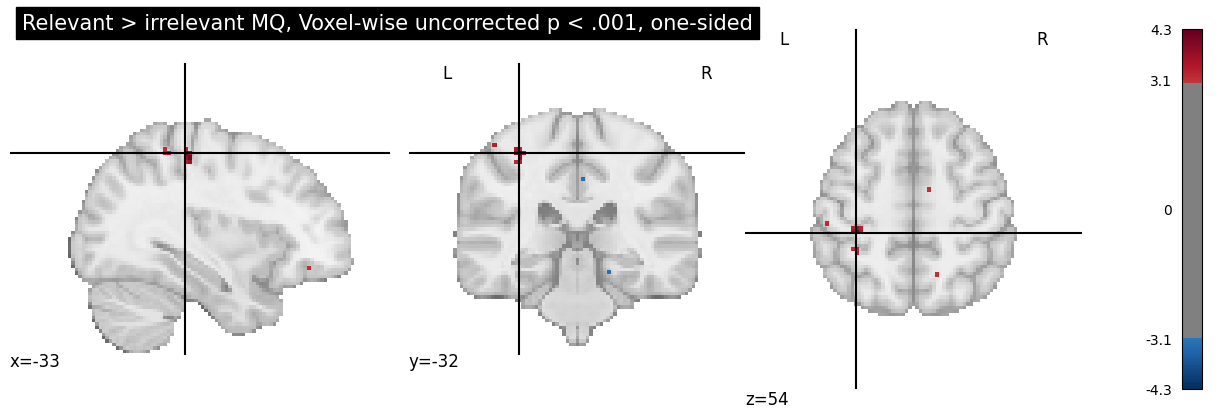

Saved figure: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_relevant_gt_irrelevant_memory_quality_fpr_p001_uncorrected.png

Voxel-wise FDR q < .05, one-sided
Computed threshold: inf
Saved thresholded map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/maps/group_relevant_gt_irrelevant_memory_quality_smoothed5mm_fdr_q05.nii.gz


/tmp/ipykernel_194225/51919680.py:50: UserWarning: The given float value must not exceed 4.268709182739258. But, you have given threshold=inf.
  thresholded_img, threshold_value = threshold_stats_img(
/tmp/ipykernel_194225/51919680.py:67: UserWarning: The given float value must not exceed 4.268709182739258. But, you have given threshold=inf.
  cluster_table = get_clusters_table(
/tmp/ipykernel_194225/51919680.py:67: UserWarning: No clusters found with stat higher than inf
  cluster_table = get_clusters_table(


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),threshold_name,height_control,alpha,computed_z_threshold,contrast


/tmp/ipykernel_194225/51919680.py:104: UserWarning: empty mask
  plot_stat_map(


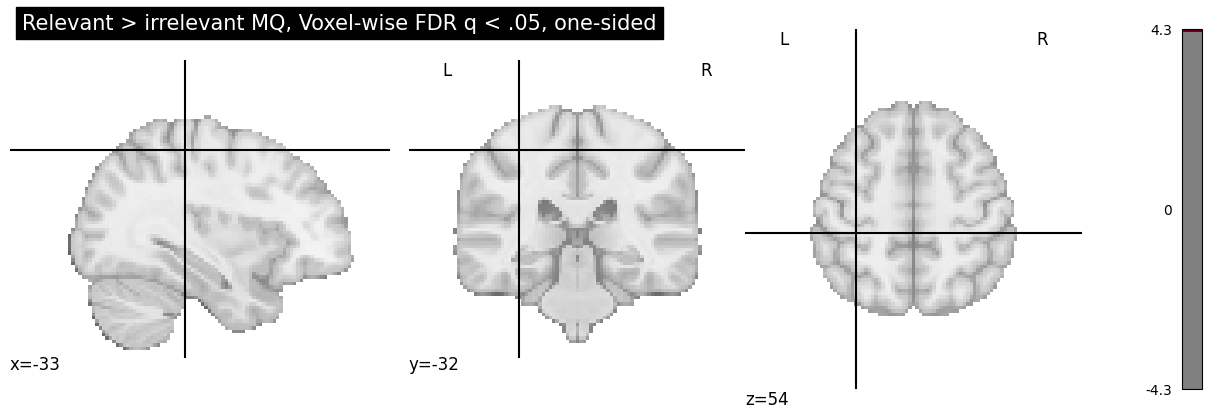

Saved figure: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_relevant_gt_irrelevant_memory_quality_fdr_q05.png

Voxel-wise FDR q < .10, one-sided exploratory
Computed threshold: inf
Saved thresholded map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/maps/group_relevant_gt_irrelevant_memory_quality_smoothed5mm_fdr_q10.nii.gz


/tmp/ipykernel_194225/51919680.py:50: UserWarning: The given float value must not exceed 4.268709182739258. But, you have given threshold=inf.
  thresholded_img, threshold_value = threshold_stats_img(
/tmp/ipykernel_194225/51919680.py:67: UserWarning: The given float value must not exceed 4.268709182739258. But, you have given threshold=inf.
  cluster_table = get_clusters_table(
/tmp/ipykernel_194225/51919680.py:67: UserWarning: No clusters found with stat higher than inf
  cluster_table = get_clusters_table(


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),threshold_name,height_control,alpha,computed_z_threshold,contrast


/tmp/ipykernel_194225/51919680.py:104: UserWarning: empty mask
  plot_stat_map(


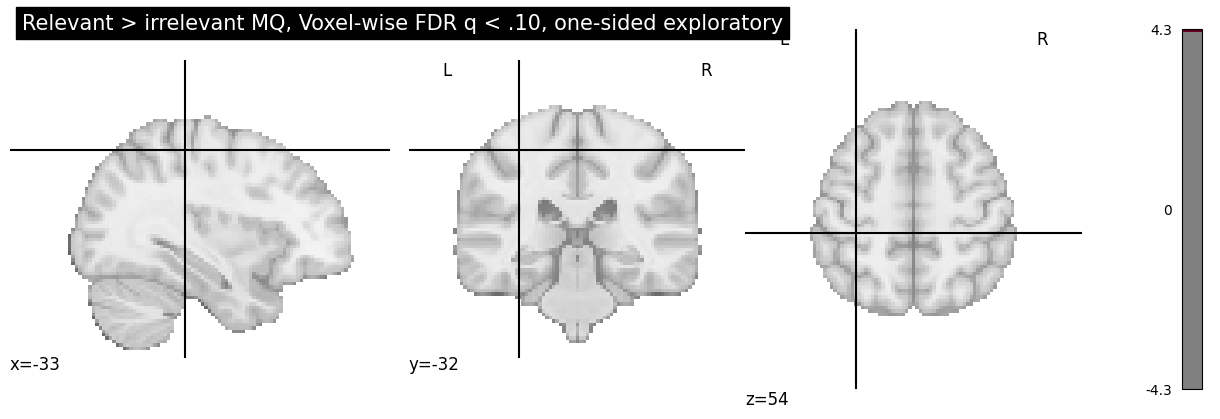

Saved figure: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_relevant_gt_irrelevant_memory_quality_fdr_q10.png

Voxel-wise Bonferroni p < .05, one-sided
Computed threshold: 4.944055204816593
Saved thresholded map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/maps/group_relevant_gt_irrelevant_memory_quality_smoothed5mm_bonferroni_p05.nii.gz


/tmp/ipykernel_194225/51919680.py:50: UserWarning: The given float value must not exceed 4.268709182739258. But, you have given threshold=4.944055204816593.
  thresholded_img, threshold_value = threshold_stats_img(
/tmp/ipykernel_194225/51919680.py:67: UserWarning: The given float value must not exceed 4.268709182739258. But, you have given threshold=4.944055204816593.
  cluster_table = get_clusters_table(
/tmp/ipykernel_194225/51919680.py:67: UserWarning: No clusters found with stat higher than 4.944055204816593
  cluster_table = get_clusters_table(


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),threshold_name,height_control,alpha,computed_z_threshold,contrast


/tmp/ipykernel_194225/51919680.py:104: UserWarning: empty mask
  plot_stat_map(


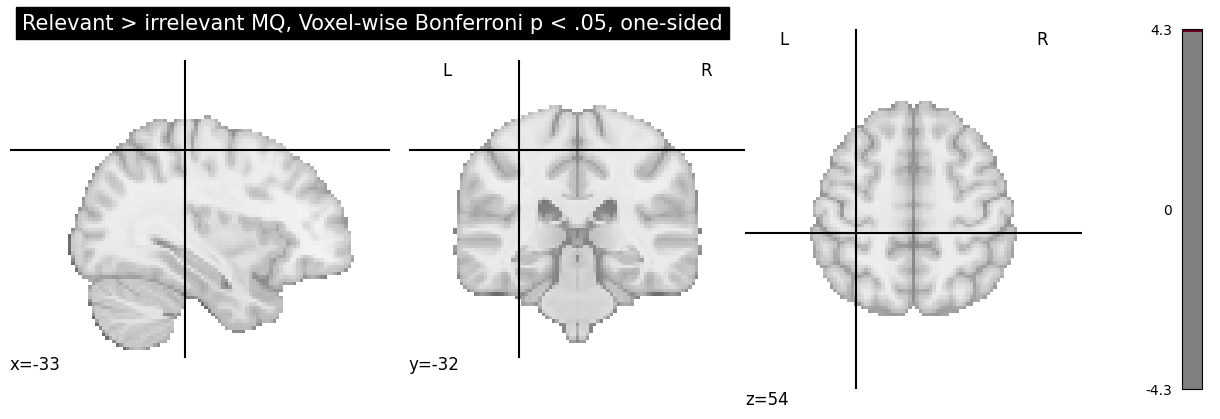

Saved figure: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/group_relevant_gt_irrelevant_memory_quality_bonferroni_p05.png

Corrected threshold summary:


,contrast,threshold_name,description,height_control,alpha,two_sided,computed_z_threshold,n_cluster_rows,max_peak_stat,thresholded_map_path,cluster_table_path
0,relevant_gt_irrelevant_memory_quality,fpr_p001_uncorrected,"Voxel-wise uncorrected p < .001, one-sided",fpr,0.001,False,3.090232,62,4.268709,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,relevant_gt_irrelevant_memory_quality,fdr_q05,"Voxel-wise FDR q < .05, one-sided",fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,relevant_gt_irrelevant_memory_quality,fdr_q10,"Voxel-wise FDR q < .10, one-sided exploratory",fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,relevant_gt_irrelevant_memory_quality,bonferroni_p05,"Voxel-wise Bonferroni p < .05, one-sided",bonferroni,0.050,False,4.944055,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/interaction_corrected_threshold_summary.csv


In [11]:
# ============================================================
# 11. Corrected thresholding for key whole-brain interaction contrast
# ============================================================

from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_stat_map
from nilearn.reporting import get_clusters_table

interaction_contrast = "relevant_gt_irrelevant_memory_quality"
interaction_z_img = nib.load(str(get_group_z_map(interaction_contrast)))

corrected_threshold_rows = []

thresholding_specs = [
    {
        "name": "fpr_p001_uncorrected",
        "height_control": "fpr",
        "alpha": 0.001,
        "two_sided": False,
        "description": "Voxel-wise uncorrected p < .001, one-sided",
    },
    {
        "name": "fdr_q05",
        "height_control": "fdr",
        "alpha": 0.05,
        "two_sided": False,
        "description": "Voxel-wise FDR q < .05, one-sided",
    },
    {
        "name": "fdr_q10",
        "height_control": "fdr",
        "alpha": 0.10,
        "two_sided": False,
        "description": "Voxel-wise FDR q < .10, one-sided exploratory",
    },
    {
        "name": "bonferroni_p05",
        "height_control": "bonferroni",
        "alpha": 0.05,
        "two_sided": False,
        "description": "Voxel-wise Bonferroni p < .05, one-sided",
    },
]

for spec in thresholding_specs:
    print("\n" + "=" * 80)
    print(spec["description"])
    
    try:
        thresholded_img, threshold_value = threshold_stats_img(
            stat_img=interaction_z_img,
            alpha=spec["alpha"],
            height_control=spec["height_control"],
            two_sided=spec["two_sided"],
        )
        
        thresholded_path = (
            WHOLE_BRAIN_MAP_DIR
            / f"group_{interaction_contrast}_{SMOOTHING_LABEL}_{spec['name']}.nii.gz"
        )
        thresholded_img.to_filename(thresholded_path)
        
        print("Computed threshold:", threshold_value)
        print("Saved thresholded map:", thresholded_path)
        
        # Cluster table after corrected threshold
        cluster_table = get_clusters_table(
            stat_img=interaction_z_img,
            stat_threshold=threshold_value,
            cluster_threshold=0,
            min_distance=8,
        )
        
        cluster_table["threshold_name"] = spec["name"]
        cluster_table["height_control"] = spec["height_control"]
        cluster_table["alpha"] = spec["alpha"]
        cluster_table["computed_z_threshold"] = threshold_value
        cluster_table["contrast"] = interaction_contrast
        
        table_path = (
            WHOLE_BRAIN_TABLE_DIR
            / f"cluster_table_{interaction_contrast}_{spec['name']}.csv"
        )
        cluster_table.to_csv(table_path, index=False)
        
        display(cluster_table)
        
        corrected_threshold_rows.append({
            "contrast": interaction_contrast,
            "threshold_name": spec["name"],
            "description": spec["description"],
            "height_control": spec["height_control"],
            "alpha": spec["alpha"],
            "two_sided": spec["two_sided"],
            "computed_z_threshold": threshold_value,
            "n_cluster_rows": len(cluster_table),
            "max_peak_stat": cluster_table["Peak Stat"].max() if len(cluster_table) > 0 else np.nan,
            "thresholded_map_path": str(thresholded_path),
            "cluster_table_path": str(table_path),
        })
        
        # Plot
        fig = plt.figure(figsize=(12, 4))
        plot_stat_map(
            interaction_z_img,
            threshold=threshold_value,
            display_mode="ortho",
            cut_coords=(-33.5, -32.0, 54.5),
            title=f"Relevant > irrelevant MQ, {spec['description']}",
            figure=fig,
        )
        
        fig_path = (
            WHOLE_BRAIN_FIG_DIR
            / f"group_{interaction_contrast}_{spec['name']}.png"
        )
        fig.savefig(fig_path, dpi=250, bbox_inches="tight")
        plt.show()
        
        print("Saved figure:", fig_path)
        
    except Exception as exc:
        print("Failed:", exc)
        corrected_threshold_rows.append({
            "contrast": interaction_contrast,
            "threshold_name": spec["name"],
            "description": spec["description"],
            "height_control": spec["height_control"],
            "alpha": spec["alpha"],
            "two_sided": spec["two_sided"],
            "computed_z_threshold": np.nan,
            "n_cluster_rows": np.nan,
            "max_peak_stat": np.nan,
            "thresholded_map_path": None,
            "cluster_table_path": None,
            "error": str(exc),
        })

corrected_threshold_summary = pd.DataFrame(corrected_threshold_rows)

corrected_threshold_summary_path = (
    WHOLE_BRAIN_TABLE_DIR
    / "interaction_corrected_threshold_summary.csv"
)
corrected_threshold_summary.to_csv(corrected_threshold_summary_path, index=False)

print("\nCorrected threshold summary:")
display(corrected_threshold_summary)

print("Saved:")
print(corrected_threshold_summary_path)

In [12]:
# ============================================================
# 12. Extract subject-level effects at strict interaction peaks
# Descriptive QC only: peaks were selected from the same group contrast.
# ============================================================

from nilearn.maskers import NiftiSpheresMasker

interaction_contrast = "relevant_gt_irrelevant_memory_quality"

strict_interaction_peaks = pd.DataFrame([
    {
        "peak_name": "left_postcentral_peak",
        "x": -33.5,
        "y": -32.0,
        "z": 54.5,
        "atlas_label": "Postcentral Gyrus",
    },
    {
        "peak_name": "left_superior_parietal_peak",
        "x": -36.0,
        "y": -44.5,
        "z": 59.5,
        "atlas_label": "Superior Parietal Lobule",
    },
    {
        "peak_name": "right_supramarginal_peak",
        "x": 61.5,
        "y": -27.0,
        "z": 47.0,
        "atlas_label": "Supramarginal Gyrus, anterior division",
    },
])

display(strict_interaction_peaks)

SPHERE_RADIUS_MM = 6

peak_effect_rows = []

for _, peak in strict_interaction_peaks.iterrows():
    coords = [(peak["x"], peak["y"], peak["z"])]
    
    masker = NiftiSpheresMasker(
        seeds=coords,
        radius=SPHERE_RADIUS_MM,
        standardize=False,
    )
    
    for subject in primary_subjects_final:
        effect_map_path = (
            FIRST_LEVEL_SMOOTHED_MAPS_DIR
            / f"{subject}_{interaction_contrast}_{SMOOTHING_LABEL}_effect.nii.gz"
        )
        
        assert effect_map_path.exists(), f"Missing effect map: {effect_map_path}"
        
        effect_img = nib.load(str(effect_map_path))
        
        extracted = masker.fit_transform(effect_img)
        extracted = np.asarray(extracted).ravel()
        
        assert extracted.size >= 1, (
            f"No value extracted for {subject}, {peak['peak_name']}"
        )
        
        mean_effect = float(extracted[0])
        
        peak_effect_rows.append({
            "subject": subject,
            "contrast": interaction_contrast,
            "peak_name": peak["peak_name"],
            "atlas_label": peak["atlas_label"],
            "x": peak["x"],
            "y": peak["y"],
            "z": peak["z"],
            "sphere_radius_mm": SPHERE_RADIUS_MM,
            "mean_effect": mean_effect,
            "effect_map_path": str(effect_map_path),
            "note": "descriptive_QC_peak_selected_from_group_map",
        })

strict_peak_subject_effects = pd.DataFrame(peak_effect_rows)

print("Subject-level peak/sphere extraction:")
display(strict_peak_subject_effects.head())

print("\nSummary by peak:")
peak_subject_summary = (
    strict_peak_subject_effects
    .groupby(["peak_name", "atlas_label"])
    .agg(
        n_subjects=("subject", "count"),
        mean_effect=("mean_effect", "mean"),
        sd_effect=("mean_effect", "std"),
        min_effect=("mean_effect", "min"),
        max_effect=("mean_effect", "max"),
        n_positive=("mean_effect", lambda x: int((x > 0).sum())),
        n_negative=("mean_effect", lambda x: int((x < 0).sum())),
    )
    .reset_index()
)

peak_subject_summary["proportion_positive"] = (
    peak_subject_summary["n_positive"] / peak_subject_summary["n_subjects"]
)

display(peak_subject_summary)

strict_peak_subject_effects_path = (
    WHOLE_BRAIN_TABLE_DIR
    / "strict_interaction_peak_subject_effects_descriptive_qc.csv"
)
strict_peak_subject_effects.to_csv(strict_peak_subject_effects_path, index=False)

peak_subject_summary_path = (
    WHOLE_BRAIN_TABLE_DIR
    / "strict_interaction_peak_subject_effect_summary_descriptive_qc.csv"
)
peak_subject_summary.to_csv(peak_subject_summary_path, index=False)

print("Saved:")
print(strict_peak_subject_effects_path)
print(peak_subject_summary_path)

,peak_name,x,y,z,atlas_label
0,left_postcentral_peak,-33.5,-32.0,54.5,Postcentral Gyrus
1,left_superior_parietal_peak,-36.0,-44.5,59.5,Superior Parietal Lobule
2,right_supramarginal_peak,61.5,-27.0,47.0,"Supramarginal Gyrus, anterior division"


Subject-level peak/sphere extraction:


,subject,contrast,peak_name,atlas_label,x,y,z,sphere_radius_mm,mean_effect,effect_map_path,note
0,sub-P10,relevant_gt_irrelevant_memory_quality,left_postcentral_peak,Postcentral Gyrus,-33.5,-32.0,54.5,6,-0.055944,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,descriptive_QC_peak_selected_from_group_map
1,sub-P12,relevant_gt_irrelevant_memory_quality,left_postcentral_peak,Postcentral Gyrus,-33.5,-32.0,54.5,6,0.060915,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,descriptive_QC_peak_selected_from_group_map
2,sub-P13,relevant_gt_irrelevant_memory_quality,left_postcentral_peak,Postcentral Gyrus,-33.5,-32.0,54.5,6,0.088452,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,descriptive_QC_peak_selected_from_group_map
3,sub-P14,relevant_gt_irrelevant_memory_quality,left_postcentral_peak,Postcentral Gyrus,-33.5,-32.0,54.5,6,-0.023399,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,descriptive_QC_peak_selected_from_group_map
4,sub-P15,relevant_gt_irrelevant_memory_quality,left_postcentral_peak,Postcentral Gyrus,-33.5,-32.0,54.5,6,-0.067561,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,descriptive_QC_peak_selected_from_group_map



Summary by peak:


,peak_name,atlas_label,n_subjects,mean_effect,sd_effect,min_effect,max_effect,n_positive,n_negative,proportion_positive
0,left_postcentral_peak,Postcentral Gyrus,28,0.043038,0.055417,-0.067561,0.138538,22,6,0.785714
1,left_superior_parietal_peak,Superior Parietal Lobule,28,0.047885,0.071234,-0.074436,0.179163,20,8,0.714286
2,right_supramarginal_peak,"Supramarginal Gyrus, anterior division",28,0.039367,0.065230,-0.094106,0.195256,20,8,0.714286


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/strict_interaction_peak_subject_effects_descriptive_qc.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/strict_interaction_peak_subject_effect_summary_descriptive_qc.csv


Descriptive one-sample summaries at strict interaction peaks:


,peak_name,atlas_label,n_subjects,mean_effect,sd_effect,sem_effect,t_stat_descriptive,p_two_sided_descriptive,p_one_sided_positive_descriptive,cohens_dz_descriptive,ci_low_95,ci_high_95,important_note
0,left_postcentral_peak,Postcentral Gyrus,28,0.043038,0.055417,0.010473,4.109500,0.000331,0.000166,0.776622,0.021550,0.064527,descriptive only; peak selected from same grou...
1,left_superior_parietal_peak,Superior Parietal Lobule,28,0.047885,0.071234,0.013462,3.557085,0.001410,0.000705,0.672226,0.020264,0.075507,descriptive only; peak selected from same grou...
2,right_supramarginal_peak,"Supramarginal Gyrus, anterior division",28,0.039367,0.065230,0.012327,3.193481,0.003557,0.001779,0.603511,0.014073,0.064660,descriptive only; peak selected from same grou...


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/strict_interaction_peak_descriptive_one_sample_summaries.csv


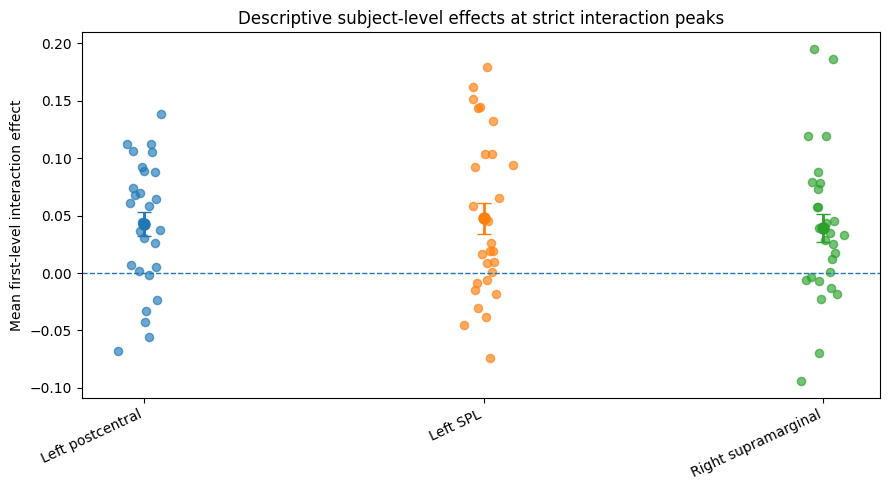

Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/strict_interaction_peak_subject_effects_descriptive_qc.png


In [13]:
# ============================================================
# 13. Plot descriptive subject-level effects at strict peaks
# ============================================================

from scipy import stats

peak_test_rows = []

for peak_name, df in strict_peak_subject_effects.groupby("peak_name"):
    values = df["mean_effect"].values
    
    t_stat, p_two_sided = stats.ttest_1samp(values, popmean=0)
    
    if t_stat >= 0:
        p_one_sided_positive = p_two_sided / 2
    else:
        p_one_sided_positive = 1 - (p_two_sided / 2)
    
    mean_effect = np.mean(values)
    sd_effect = np.std(values, ddof=1)
    sem_effect = sd_effect / np.sqrt(len(values))
    cohens_dz = mean_effect / sd_effect
    
    ci_low, ci_high = stats.t.interval(
        confidence=0.95,
        df=len(values) - 1,
        loc=mean_effect,
        scale=sem_effect,
    )
    
    peak_test_rows.append({
        "peak_name": peak_name,
        "atlas_label": df["atlas_label"].iloc[0],
        "n_subjects": len(values),
        "mean_effect": mean_effect,
        "sd_effect": sd_effect,
        "sem_effect": sem_effect,
        "t_stat_descriptive": t_stat,
        "p_two_sided_descriptive": p_two_sided,
        "p_one_sided_positive_descriptive": p_one_sided_positive,
        "cohens_dz_descriptive": cohens_dz,
        "ci_low_95": ci_low,
        "ci_high_95": ci_high,
        "important_note": "descriptive only; peak selected from same group map",
    })

strict_peak_tests = pd.DataFrame(peak_test_rows)

print("Descriptive one-sample summaries at strict interaction peaks:")
display(strict_peak_tests)

strict_peak_tests_path = (
    WHOLE_BRAIN_TABLE_DIR
    / "strict_interaction_peak_descriptive_one_sample_summaries.csv"
)
strict_peak_tests.to_csv(strict_peak_tests_path, index=False)

print("Saved:")
print(strict_peak_tests_path)


# Plot
fig, ax = plt.subplots(figsize=(9, 5))

peak_order = [
    "left_postcentral_peak",
    "left_superior_parietal_peak",
    "right_supramarginal_peak",
]

peak_labels = {
    "left_postcentral_peak": "Left postcentral",
    "left_superior_parietal_peak": "Left SPL",
    "right_supramarginal_peak": "Right supramarginal",
}

rng = np.random.default_rng(42)
x_positions = np.arange(len(peak_order))

for i, peak_name in enumerate(peak_order):
    values = strict_peak_subject_effects.loc[
        strict_peak_subject_effects["peak_name"] == peak_name,
        "mean_effect",
    ].values
    
    jitter = rng.normal(loc=0, scale=0.04, size=len(values))
    
    ax.scatter(
        np.full(len(values), x_positions[i]) + jitter,
        values,
        alpha=0.65,
        s=35,
    )
    
    mean_val = np.mean(values)
    sem_val = np.std(values, ddof=1) / np.sqrt(len(values))
    
    ax.errorbar(
        x_positions[i],
        mean_val,
        yerr=sem_val,
        marker="o",
        markersize=8,
        capsize=5,
        linewidth=2,
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x_positions)
ax.set_xticklabels([peak_labels[p] for p in peak_order], rotation=25, ha="right")
ax.set_ylabel("Mean first-level interaction effect")
ax.set_title("Descriptive subject-level effects at strict interaction peaks")
plt.tight_layout()

peak_plot_path = WHOLE_BRAIN_FIG_DIR / "strict_interaction_peak_subject_effects_descriptive_qc.png"
fig.savefig(peak_plot_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:")
print(peak_plot_path)

In [14]:
# ============================================================
# 14. Whole-brain inference summary
# ============================================================

whole_brain_inference_summary = pd.DataFrame([
    {
        "result": "relevant_gt_irrelevant_memory_quality",
        "threshold": "voxel-wise uncorrected p < .001 one-sided",
        "z_threshold": 3.090232,
        "survives": True,
        "interpretation": (
            "Exploratory uncorrected evidence for stronger memory-quality "
            "modulation for relevant than irrelevant images."
        ),
    },
    {
        "result": "relevant_gt_irrelevant_memory_quality",
        "threshold": "voxel-wise FDR q < .05 one-sided",
        "z_threshold": np.inf,
        "survives": False,
        "interpretation": (
            "Does not survive voxel-wise FDR correction; should not be "
            "reported as corrected whole-brain significant."
        ),
    },
    {
        "result": "relevant_gt_irrelevant_memory_quality",
        "threshold": "voxel-wise FDR q < .10 one-sided",
        "z_threshold": np.inf,
        "survives": False,
        "interpretation": (
            "Does not survive liberal voxel-wise FDR correction; remains "
            "an exploratory uncorrected whole-brain finding."
        ),
    },
    {
        "result": "relevant_gt_irrelevant_memory_quality",
        "threshold": "voxel-wise Bonferroni p < .05 one-sided",
        "z_threshold": 4.944055,
        "survives": False,
        "interpretation": (
            "Does not survive conservative voxel-wise Bonferroni correction."
        ),
    },
])

display(whole_brain_inference_summary)

whole_brain_inference_summary_path = (
    WHOLE_BRAIN_TABLE_DIR
    / "whole_brain_inference_summary.csv"
)
whole_brain_inference_summary.to_csv(whole_brain_inference_summary_path, index=False)

print("Saved:")
print(whole_brain_inference_summary_path)

,result,threshold,z_threshold,survives,interpretation
0,relevant_gt_irrelevant_memory_quality,voxel-wise uncorrected p < .001 one-sided,3.090232,True,Exploratory uncorrected evidence for stronger ...
1,relevant_gt_irrelevant_memory_quality,voxel-wise FDR q < .05 one-sided,inf,False,Does not survive voxel-wise FDR correction; sh...
2,relevant_gt_irrelevant_memory_quality,voxel-wise FDR q < .10 one-sided,inf,False,Does not survive liberal voxel-wise FDR correc...
3,relevant_gt_irrelevant_memory_quality,voxel-wise Bonferroni p < .05 one-sided,4.944055,False,Does not survive conservative voxel-wise Bonfe...


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/whole_brain_inference_summary.csv


### Whole-brain exploratory interaction: relevant > irrelevant memory quality

The strongest whole-brain result was the interaction contrast testing whether item-level memory-quality modulation was stronger for goal-relevant than goal-irrelevant images. At a voxel-wise uncorrected threshold of p < .001 one-sided (z > 3.09), three small clusters were observed, with peaks in left postcentral gyrus, left superior parietal lobule, and right anterior supramarginal gyrus. These regions fall within or near dorsal parietal/fronto-parietal systems often implicated in goal-directed attention and attentional aspects of episodic retrieval.

However, the contrast did not survive voxel-wise FDR correction at q < .05 or q < .10, nor Bonferroni correction. Therefore, this result should be interpreted as exploratory rather than corrected whole-brain significant. Descriptive extraction of first-level effects from 6 mm spheres around the three strict peaks suggested that the positive interaction was present in a majority of participants, but these values were used only for visualization and outlier checking because the peaks were selected from the same group-level contrast.

Together, the whole-brain results suggest that goal relevance may modulate the relationship between post-viewing brain activity and later memory quality in dorsal parietal/fronto-parietal regions, whereas the hippocampus/MTL ROI analyses did not show a reliable positive modulation.

The **relevant > irrelevant memory-quality** contrast tests whether the brain activity associated with *better later memory quality* is stronger for **goal-relevant images** than for **goal-irrelevant images** during the post-viewing phase. In other words, it is not simply “remembered relevant images vs forgotten irrelevant images”; it is a comparison of the **slope** between memory quality and BOLD activity in relevant items versus the same slope in irrelevant items.

Memory quality was defined at the image level by combining two behavioral measures: **spatial precision** and **confidence**. Spatial precision entered as negative spatial error, so images placed closer to their true location had higher spatial accuracy; confidence entered as the participant’s reported confidence, normalized within participant. These two components were averaged into one memory-quality score, then condition-centered separately for relevant and irrelevant images before entering the GLM as parametric modulators.

So the contrast asks: *for images that are later remembered with higher spatial precision and confidence, does post-viewing activity increase more when those images were goal-relevant than when they were goal-irrelevant?*

A positive activation means that the region tracks memory quality more strongly for relevant images than for irrelevant images.

Loading:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_behavior_item_level_memory_quality.csv
exists: True
Columns:
['subject', 'image_file', 'spatial_error', 'spatial_accuracy', 'confidence', 'goal_relevant', 'goal_irrelevant', 'recalled_x', 'recalled_z', 'checkpoint_x', 'checkpoint_z', 'spatial_accuracy_z', 'confidence_z', 'memory_quality_raw', 'memory_quality_z', 'relevance_condition', 'memory_quality_condition_centered']

Rows: 1045
Subjects: 28

Counts by relevance:


,relevance_condition,n_images,n_subjects,mean_memory_quality_z,sd_memory_quality_z,mean_condition_centered_mq,sd_condition_centered_mq,min_condition_centered_mq,max_condition_centered_mq
0,irrelevant,505,28,-0.089188,1.000451,3.077846e-18,0.987435,-2.919007,4.514794
1,relevant,540,28,0.083408,0.994205,1.233581e-18,0.983628,-3.221088,4.732418


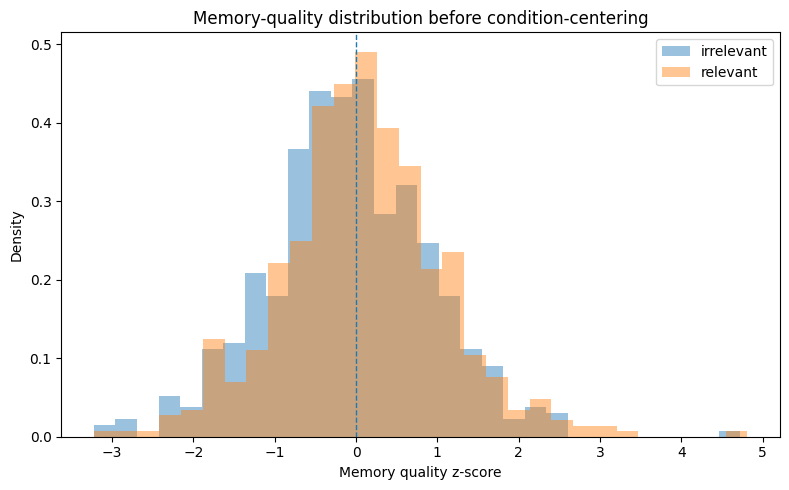

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/memory_quality_distribution_by_relevance_before_condition_centering.png


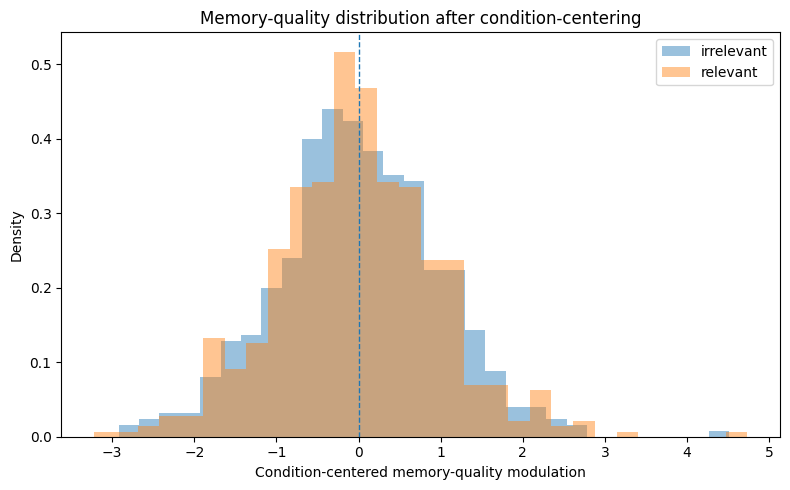

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/memory_quality_distribution_by_relevance_condition_centered.png


,subject,relevance_condition,n_images,mean_mq,sd_mq,min_mq,max_mq,range_mq
0,sub-P10,irrelevant,12,1.850372e-17,0.972223,-1.303069,2.026605,3.329674
1,sub-P10,relevant,16,7.285839e-17,1.082039,-1.515159,2.343302,3.858461
2,sub-P12,irrelevant,12,-1.734723e-17,0.766147,-1.238127,1.280584,2.518711
3,sub-P12,relevant,18,0.000000e+00,1.175062,-2.594445,2.226560,4.821005
4,sub-P13,irrelevant,21,-1.321694e-17,0.996033,-2.068001,1.781953,3.849954


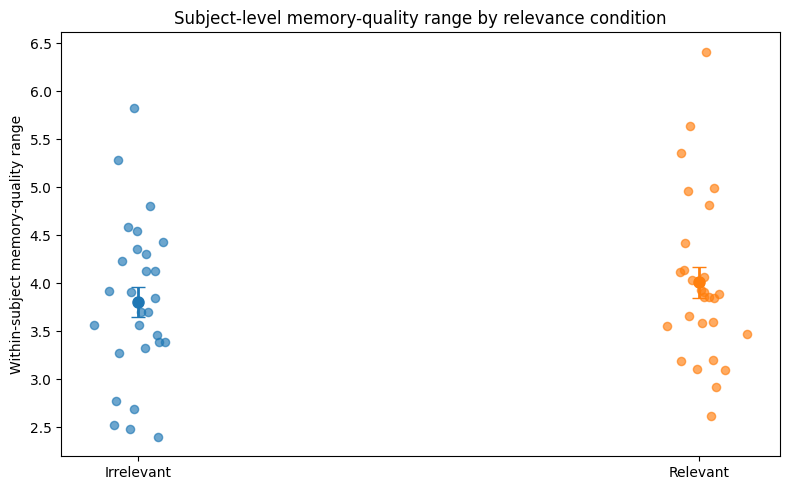

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/figures/subject_level_memory_quality_range_by_relevance.png

Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/memory_quality_distribution_by_relevance_summary.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/whole_brain_followup/tables/subject_level_memory_quality_range_by_relevance.csv


In [15]:
# ============================================================
# 15. Check memory-quality distribution by relevance condition
# ============================================================

import seaborn as sns  # only for quick density visualization

memory_quality_path = TABLE_DIR / "final_behavior_item_level_memory_quality.csv"

print("Loading:")
print(memory_quality_path)
print("exists:", memory_quality_path.exists())

assert memory_quality_path.exists(), "Memory-quality item-level table not found."

mq_df = pd.read_csv(memory_quality_path)

print("Columns:")
print(mq_df.columns.tolist())

# Keep only valid rows with memory-quality values
mq_plot_df = mq_df.dropna(
    subset=[
        "memory_quality_z",
        "memory_quality_condition_centered",
        "relevance_condition",
    ]
).copy()

print("\nRows:", len(mq_plot_df))
print("Subjects:", mq_plot_df["subject"].nunique())

print("\nCounts by relevance:")
display(
    mq_plot_df
    .groupby("relevance_condition")
    .agg(
        n_images=("image_file", "count"),
        n_subjects=("subject", "nunique"),
        mean_memory_quality_z=("memory_quality_z", "mean"),
        sd_memory_quality_z=("memory_quality_z", "std"),
        mean_condition_centered_mq=("memory_quality_condition_centered", "mean"),
        sd_condition_centered_mq=("memory_quality_condition_centered", "std"),
        min_condition_centered_mq=("memory_quality_condition_centered", "min"),
        max_condition_centered_mq=("memory_quality_condition_centered", "max"),
    )
    .reset_index()
)

# ------------------------------------------------------------
# Plot 1: raw subject-z memory quality by relevance
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

for condition in ["irrelevant", "relevant"]:
    values = mq_plot_df.loc[
        mq_plot_df["relevance_condition"] == condition,
        "memory_quality_z",
    ]
    ax.hist(
        values,
        bins=30,
        alpha=0.45,
        density=True,
        label=condition,
    )

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Memory quality z-score")
ax.set_ylabel("Density")
ax.set_title("Memory-quality distribution before condition-centering")
ax.legend()
plt.tight_layout()

out_path = WHOLE_BRAIN_FIG_DIR / "memory_quality_distribution_by_relevance_before_condition_centering.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ------------------------------------------------------------
# Plot 2: condition-centered memory quality by relevance
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

for condition in ["irrelevant", "relevant"]:
    values = mq_plot_df.loc[
        mq_plot_df["relevance_condition"] == condition,
        "memory_quality_condition_centered",
    ]
    ax.hist(
        values,
        bins=30,
        alpha=0.45,
        density=True,
        label=condition,
    )

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Condition-centered memory-quality modulation")
ax.set_ylabel("Density")
ax.set_title("Memory-quality distribution after condition-centering")
ax.legend()
plt.tight_layout()

out_path = WHOLE_BRAIN_FIG_DIR / "memory_quality_distribution_by_relevance_condition_centered.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ------------------------------------------------------------
# Plot 3: subject-level ranges by relevance
# ------------------------------------------------------------

subject_range_df = (
    mq_plot_df
    .groupby(["subject", "relevance_condition"])
    .agg(
        n_images=("image_file", "count"),
        mean_mq=("memory_quality_condition_centered", "mean"),
        sd_mq=("memory_quality_condition_centered", "std"),
        min_mq=("memory_quality_condition_centered", "min"),
        max_mq=("memory_quality_condition_centered", "max"),
    )
    .reset_index()
)

subject_range_df["range_mq"] = subject_range_df["max_mq"] - subject_range_df["min_mq"]

display(subject_range_df.head())

fig, ax = plt.subplots(figsize=(8, 5))

conditions = ["irrelevant", "relevant"]
x_positions = np.arange(len(conditions))
rng = np.random.default_rng(42)

for i, condition in enumerate(conditions):
    values = subject_range_df.loc[
        subject_range_df["relevance_condition"] == condition,
        "range_mq",
    ].values
    
    jitter = rng.normal(loc=0, scale=0.04, size=len(values))
    
    ax.scatter(
        np.full(len(values), x_positions[i]) + jitter,
        values,
        alpha=0.65,
        s=35,
    )
    
    mean_val = np.mean(values)
    sem_val = np.std(values, ddof=1) / np.sqrt(len(values))
    
    ax.errorbar(
        x_positions[i],
        mean_val,
        yerr=sem_val,
        marker="o",
        markersize=8,
        capsize=5,
        linewidth=2,
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(["Irrelevant", "Relevant"])
ax.set_ylabel("Within-subject memory-quality range")
ax.set_title("Subject-level memory-quality range by relevance condition")
plt.tight_layout()

out_path = WHOLE_BRAIN_FIG_DIR / "subject_level_memory_quality_range_by_relevance.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------

mq_distribution_summary_path = WHOLE_BRAIN_TABLE_DIR / "memory_quality_distribution_by_relevance_summary.csv"
subject_range_path = WHOLE_BRAIN_TABLE_DIR / "subject_level_memory_quality_range_by_relevance.csv"

(
    mq_plot_df
    .groupby("relevance_condition")
    .agg(
        n_images=("image_file", "count"),
        n_subjects=("subject", "nunique"),
        mean_memory_quality_z=("memory_quality_z", "mean"),
        sd_memory_quality_z=("memory_quality_z", "std"),
        mean_condition_centered_mq=("memory_quality_condition_centered", "mean"),
        sd_condition_centered_mq=("memory_quality_condition_centered", "std"),
        min_condition_centered_mq=("memory_quality_condition_centered", "min"),
        max_condition_centered_mq=("memory_quality_condition_centered", "max"),
    )
    .reset_index()
    .to_csv(mq_distribution_summary_path, index=False)
)

subject_range_df.to_csv(subject_range_path, index=False)

print("\nSaved:")
print(mq_distribution_summary_path)
print(subject_range_path)

The memory-quality distributions were inspected to verify that the relevant > irrelevant memory-quality contrast was not trivially driven by mean differences in memory quality. Before condition-centering, relevant images showed slightly higher memory quality on average than irrelevant images. However, after condition-centering within each subject and relevance condition, both relevant and irrelevant modulators were centered at zero and had highly similar variance. Therefore, the GLM interaction contrast compares within-condition memory-quality slopes rather than simply contrasting better-remembered relevant images against worse-remembered irrelevant images.

The primary memory-quality regressor used within-subject normalized confidence because participants differed substantially in how they used the confidence scale. This convention treats confidence as a relative judgment within participant, which is appropriate for a first-level parametric GLM. As a sensitivity check, we also evaluated a raw-confidence convention; this produced a weaker behavioral relevance effect, suggesting that much of the raw scale variation reflected participant-specific scale use rather than item-level memory quality.